In [8]:
import yfinance as yf
import pandas as pd
from datetime import datetime
import time
import numpy as np

# CONFIG
start_date = '1990-01-01'
end_date   = '2026-02-25'
risk_free_symbol = '^IRX'

# S&P 500 TICKER LIST — dynamic fetch from Wikipedia + fallback
def get_sp500_tickers():
    """Fetch current S&P 500 tickers from Wikipedia. Falls back to hardcoded list."""
    try:
        url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
        table = pd.read_html(url)[0]
        tickers = table['Symbol'].str.replace('.', '-', regex=False).tolist()
        print(f"Fetched {len(tickers)} tickers from Wikipedia")
        return tickers
    except Exception as e:
        print(f"Wikipedia fetch failed ({e}), using hardcoded list")
        return _hardcoded_sp500()


def _hardcoded_sp500():
    """Comprehensive S&P 500 list (~503 tickers, Feb 2026 composition)."""
    return [
        # Technology
        'AAPL', 'MSFT', 'NVDA', 'AVGO', 'ORCL', 'CRM', 'AMD', 'CSCO', 'ADBE', 'ACN',
        'IBM', 'INTC', 'TXN', 'QCOM', 'NOW', 'INTU', 'AMAT', 'LRCX', 'MU', 'ADI',
        'KLAC', 'SNPS', 'CDNS', 'MCHP', 'FTNT', 'PANW', 'CRWD', 'HPQ', 'HPE', 'DELL',
        'NXPI', 'ON', 'GEN', 'MPWR', 'KEYS', 'ANSS', 'CTSH', 'IT', 'EPAM', 'AKAM',
        'ENPH', 'SEDG', 'FSLR', 'ANET', 'GLW', 'MSI', 'TER', 'FFIV', 'NTAP', 'ZBRA',
        'SWKS', 'JNPR', 'TRMB', 'TYL', 'VRSN', 'WDC', 'STX', 'SNDK', 'APH', 'TEL',
        'CDW', 'PLTR',
        # Communication Services
        'GOOGL', 'GOOG', 'META', 'NFLX', 'DIS', 'CMCSA', 'T', 'VZ', 'TMUS', 'CHTR',
        'EA', 'TTWO', 'MTCH', 'ZG', 'LUMN', 'PARA', 'WBD', 'FOXA', 'FOX', 'NWS',
        'NWSA', 'LYV', 'OMC', 'IPG',
        # Consumer Discretionary
        'AMZN', 'TSLA', 'HD', 'LOW', 'MCD', 'NKE', 'SBUX', 'TJX', 'BKNG', 'CMG',
        'MAR', 'HLT', 'ORLY', 'AZO', 'ROST', 'DHI', 'LEN', 'PHM', 'NVR', 'GM',
        'F', 'RIVN', 'APTV', 'GPC', 'EBAY', 'ULTA', 'DG', 'DLTR', 'BBY', 'TSCO',
        'POOL', 'YUM', 'DPZ', 'RCL', 'CCL', 'LVS', 'WYNN', 'MGM', 'ABNB', 'CVNA',
        'TGT', 'DRI', 'MHK', 'BWA', 'CZR', 'GNRC', 'HAS', 'LKQ', 'KMX', 'TPR',
        'EXPE', 'DAL', 'UAL', 'LUV', 'AAL', 'DECK', 'GRMN', 'ROP',
        # Consumer Staples
        'WMT', 'PG', 'COST', 'KO', 'PEP', 'PM', 'MO', 'MDLZ', 'CL', 'KMB',
        'GIS', 'K', 'SJM', 'HSY', 'CAG', 'CPB', 'HRL', 'STZ', 'TAP', 'BF-B',
        'KDP', 'MNST', 'CLX', 'CHD', 'EL', 'SYY', 'ADM', 'KVUE', 'WBA',
        # Energy
        'XOM', 'CVX', 'COP', 'SLB', 'EOG', 'MPC', 'PSX', 'VLO', 'OXY', 'DVN',
        'HAL', 'FANG', 'HES', 'BKR', 'TRGP', 'KMI', 'WMB', 'OKE', 'EQT', 'CTRA',
        'APA',
        # Financials
        'BRK-B', 'JPM', 'V', 'MA', 'BAC', 'WFC', 'GS', 'MS', 'C', 'SCHW',
        'BLK', 'SPGI', 'AXP', 'CB', 'MMC', 'PGR', 'AON', 'CME', 'ICE', 'MCO',
        'MSCI', 'AIG', 'MET', 'PRU', 'TRV', 'AFL', 'ALL', 'USB', 'PNC', 'TFC',
        'FITB', 'MTB', 'CFG', 'KEY', 'RF', 'HBAN', 'ZION', 'COF', 'DFS', 'SYF',
        'BX', 'KKR', 'APO', 'ARES', 'BK', 'STT', 'NTRS', 'RJF', 'ACGL', 'HIG',
        'WRB', 'CINF', 'GL', 'RE', 'L', 'IBKR', 'HOOD', 'COIN', 'NDAQ', 'CBOE',
        'FDS', 'MKTX', 'AMP', 'BEN', 'IVZ', 'TROW', 'GPN', 'FISV', 'FI', 'FIS',
        'AJG', 'ERIE', 'CBRE', 'RMD',
        # Healthcare
        'UNH', 'LLY', 'ABBV', 'MRK', 'PFE', 'TMO', 'ABT', 'DHR', 'BMY', 'AMGN',
        'GILD', 'MDT', 'ISRG', 'SYK', 'ELV', 'CI', 'CVS', 'HCA', 'BSX', 'ZBH',
        'REGN', 'VRTX', 'BIIB', 'ILMN', 'DXCM', 'IDXX', 'MTD', 'IQV', 'A', 'BDX',
        'EW', 'BAX', 'HOLX', 'ALGN', 'ZTS', 'CNC', 'MOH', 'HUM', 'CAH', 'MCK',
        'GEHC', 'COR', 'PODD', 'RVTY', 'TECH', 'TFX', 'HSIC', 'BIO', 'VTRS',
        'SOLV', 'INCY',
        # Industrials
        'CAT', 'DE', 'HON', 'UNP', 'UPS', 'BA', 'RTX', 'LMT', 'GE', 'GD',
        'NOC', 'MMM', 'ETN', 'EMR', 'ITW', 'PH', 'ROK', 'FAST', 'CTAS', 'PCAR',
        'FDX', 'CSX', 'NSC', 'WM', 'RSG', 'VRSK', 'IR', 'CMI', 'DOV', 'SWK',
        'AME', 'XYL', 'WAB', 'GEV', 'TT', 'TDG', 'LHX', 'URI', 'CARR', 'GWW',
        'ADP', 'PAYX', 'PWR', 'EME', 'FIX', 'HUBB', 'ODFL', 'JBHT', 'NDSN',
        'SNA', 'TXT', 'RHI', 'FTV', 'BR', 'AXON', 'DAL', 'UAL', 'UBER',
        # Materials
        'LIN', 'APD', 'SHW', 'ECL', 'DD', 'DOW', 'NEM', 'FCX', 'NUE', 'STLD',
        'CF', 'MOS', 'ALB', 'FMC', 'IFF', 'PPG', 'VMC', 'MLM', 'CE', 'EMN',
        'PKG', 'IP', 'WRK', 'SEE', 'CTVA', 'AVY', 'RPM', 'CRH', 'WY',
        # Real Estate
        'AMT', 'PLD', 'CCI', 'EQIX', 'PSA', 'SPG', 'O', 'WELL', 'DLR', 'AVB',
        'EQR', 'VTR', 'ARE', 'MAA', 'UDR', 'ESS', 'KIM', 'VICI', 'IRM', 'EXR',
        'SBAC', 'CPT', 'REG', 'FRT', 'PEAK', 'INVH', 'HST', 'BXP',
        # Utilities
        'NEE', 'DUK', 'SO', 'D', 'AEP', 'EXC', 'SRE', 'XEL', 'WEC', 'ED',
        'ES', 'PEG', 'AWK', 'ATO', 'CMS', 'DTE', 'FE', 'PPL', 'AEE', 'EVRG',
        'PCG', 'ETR', 'CEG', 'VST', 'NRG', 'AES', 'LNT', 'NI', 'PNW',
        # Others / recent additions
        'APP', 'DDOG', 'WDAY', 'ADSK', 'CPRT', 'FICO', 'PYPL', 'OTIS', 'JCI',
        'HWM', 'ROL', 'JKHY', 'TKO', 'PFG', 'AIZ',
    ]


sp500_stocks = get_sp500_tickers()

# Deduplicate while preserving order
sp500_stocks = list(dict.fromkeys(sp500_stocks))
print(f"Total tickers to download: {len(sp500_stocks)}")
print(f"Period: {start_date} to {end_date}")

# MACRO INDICATORS
macro_symbols = {
    '^VIX':  'VIX',
    '^GSPC': 'SP500',
    '^IRX':  'RF_13W',
    '^TNX':  'UST_10Y',
    '^FVX':  'UST_5Y',
}


# DOWNLOAD STOCK PRICES (in batches)
print("\nDOWNLOADING STOCK PRICES")
adj_close_df = pd.DataFrame()
loaded_stocks = []
failed_stocks = []

batch_size = 30
for batch_start in range(0, len(sp500_stocks), batch_size):
    batch = sp500_stocks[batch_start:batch_start + batch_size]
    batch_str = ' '.join(batch)
    batch_num = batch_start // batch_size + 1
    total_batches = (len(sp500_stocks) + batch_size - 1) // batch_size
    print(f"[Batch {batch_num}/{total_batches}] Downloading {len(batch)} tickers...")

    try:
        data = yf.download(batch_str, start=start_date, end=end_date,
                           interval='1d', auto_adjust=False, progress=False, threads=True)

        if data.empty:
            failed_stocks.extend(batch)
            continue

        if isinstance(data.columns, pd.MultiIndex):
            if 'Adj Close' in data.columns.get_level_values(0):
                prices = data['Adj Close']
            elif 'Close' in data.columns.get_level_values(0):
                prices = data['Close']
            else:
                failed_stocks.extend(batch)
                continue
        else:
            col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'
            prices = data[[col]].rename(columns={col: batch[0]})

        for stock in batch:
            if stock in prices.columns:
                series = prices[stock].dropna()
                if len(series) > 100:
                    adj_close_df[stock] = prices[stock]
                    loaded_stocks.append(stock)
                else:
                    failed_stocks.append(stock)
            else:
                failed_stocks.append(stock)

        ok_count = sum(1 for s in batch if s in loaded_stocks)
        print(f"  Loaded: {ok_count}/{len(batch)}")

    except Exception as e:
        print(f"  Error: {e}")
        failed_stocks.extend(batch)

    time.sleep(1)

print(f"\nTotal stocks loaded: {len(loaded_stocks)} / {len(sp500_stocks)}")
if failed_stocks:
    print(f"Failed ({len(failed_stocks)}): {failed_stocks[:30]}{'...' if len(failed_stocks)>30 else ''}")


# DOWNLOAD MACRO INDICATORS
print("\nDOWNLOADING MACRO INDICATORS")
macro_df = pd.DataFrame()

for symbol, name in macro_symbols.items():
    print(f"  {name:10s} ({symbol})...", end=" ")
    try:
        ticker = yf.Ticker(symbol)
        hist = ticker.history(start=start_date, end=end_date, interval='1d', auto_adjust=False)
        if not hist.empty:
            col = 'Adj Close' if 'Adj Close' in hist.columns else 'Close'
            macro_df[name] = hist[col]
            print(f"OK ({len(hist)} days)")
        else:
            print("empty")
    except Exception as e:
        print(f"Error: {e}")
    time.sleep(0.5)

# Derived macro features
if 'UST_10Y' in macro_df.columns and 'RF_13W' in macro_df.columns:
    macro_df['Term_Spread'] = macro_df['UST_10Y'] - macro_df['RF_13W']

if 'SP500' in macro_df.columns:
    macro_df['Market_Return'] = np.log(macro_df['SP500'] / macro_df['SP500'].shift(1))

if 'VIX' in macro_df.columns:
    macro_df['VIX_Change'] = macro_df['VIX'].pct_change()

if 'RF_13W' in macro_df.columns:
    macro_df['Risk_Free_Annual'] = macro_df['RF_13W'] / 100
    macro_df['Risk_Free_Daily']  = macro_df['Risk_Free_Annual'] / 252

print(f"Macro features: {list(macro_df.columns)}")


# CREDIT SPREAD FROM FRED
print("\nCREDIT SPREAD (BAA-AAA)")
try:
    import io, requests
    fred_base = 'https://fred.stlouisfed.org/graph/fredgraph.csv'

    baa_url = f"{fred_base}?id=BAA&cosd={start_date}&coed={end_date}"
    aaa_url = f"{fred_base}?id=AAA&cosd={start_date}&coed={end_date}"

    baa_resp = requests.get(baa_url, timeout=15)
    aaa_resp = requests.get(aaa_url, timeout=15)

    if baa_resp.status_code == 200 and 'DATE' in baa_resp.text[:100]:
        baa_s = pd.read_csv(io.StringIO(baa_resp.text), parse_dates=['DATE'], index_col='DATE')
        baa_s.columns = ['BAA']
        baa_s['BAA'] = pd.to_numeric(baa_s['BAA'], errors='coerce')
    else:
        baa_s = None

    if aaa_resp.status_code == 200 and 'DATE' in aaa_resp.text[:100]:
        aaa_s = pd.read_csv(io.StringIO(aaa_resp.text), parse_dates=['DATE'], index_col='DATE')
        aaa_s.columns = ['AAA']
        aaa_s['AAA'] = pd.to_numeric(aaa_s['AAA'], errors='coerce')
    else:
        aaa_s = None

    if baa_s is not None and aaa_s is not None:
        macro_df['Credit_Spread'] = baa_s['BAA'] - aaa_s['AAA']
        print("  Credit Spread added")
    else:
        print("  Credit Spread unavailable, VIX used as proxy")
except Exception as e:
    print(f"  FRED unavailable: {e}")


# SYNCHRONIZE & CLEAN
adj_close_df.index = pd.to_datetime(adj_close_df.index).tz_localize(None)
macro_df.index = pd.to_datetime(macro_df.index).tz_localize(None)
common_dates = adj_close_df.index.intersection(macro_df.index)

adj_close_filtered = adj_close_df.loc[common_dates].ffill()
macro_filtered = macro_df.loc[common_dates].ffill()

# Drop stocks with >20% missing
min_obs = int(0.8 * len(common_dates))
valid_cols = adj_close_filtered.count()[adj_close_filtered.count() >= min_obs].index
adj_close_filtered = adj_close_filtered[valid_cols]
loaded_stocks = [s for s in loaded_stocks if s in valid_cols]

# SAVE
period_tag = f"{start_date[:4]}_{end_date[:4]}"
adj_close_filtered.to_csv(f'stocks_adj_close_{period_tag}.csv')
macro_filtered.to_csv(f'macro_data_{period_tag}.csv')

print(f"\nFinal: {len(loaded_stocks)} stocks x {len(common_dates)} days = {len(loaded_stocks)*len(common_dates):,} panel obs")
print(f"Period: {common_dates.min().date()} to {common_dates.max().date()}")
print(f"Macro features: {list(macro_filtered.columns)}")

Wikipedia fetch failed (`Import lxml` failed.  Use pip or conda to install the lxml package.), using hardcoded list
Total tickers to download: 476
Period: 1990-01-01 to 2026-02-25

DOWNLOADING STOCK PRICES
[Batch 1/16] Downloading 30 tickers...
  Loaded: 30/30
[Batch 2/16] Downloading 30 tickers...


$JNPR: possibly delisted; no timezone found
$ANSS: possibly delisted; no timezone found

2 Failed downloads:
['JNPR', 'ANSS']: possibly delisted; no timezone found


  Loaded: 28/30
[Batch 3/16] Downloading 30 tickers...


$PARA: possibly delisted; no timezone found
$IPG: possibly delisted; no timezone found

2 Failed downloads:
['PARA', 'IPG']: possibly delisted; no timezone found


  Loaded: 28/30
[Batch 4/16] Downloading 30 tickers...
  Loaded: 30/30
[Batch 5/16] Downloading 30 tickers...
  Loaded: 30/30
[Batch 6/16] Downloading 30 tickers...


...

  Loaded: 28/30
[Batch 10/16] Downloading 30 tickers...
  Loaded: 30/30
[Batch 11/16] Downloading 30 tickers...
  Loaded: 30/30
[Batch 12/16] Downloading 30 tickers...
  Loaded: 30/30
[Batch 13/16] Downloading 30 tickers...
  Loaded: 30/30
[Batch 14/16] Downloading 30 tickers...


$WRK: possibly delisted; no timezone found

1 Failed download:
['WRK']: possibly delisted; no timezone found


  Loaded: 29/30
[Batch 15/16] Downloading 30 tickers...


$PEAK: possibly delisted; no timezone found

1 Failed download:
['PEAK']: possibly delisted; no timezone found


  Loaded: 29/30
[Batch 16/16] Downloading 26 tickers...
  Loaded: 26/26

Total stocks loaded: 464 / 476
Failed (12): ['ANSS', 'JNPR', 'PARA', 'IPG', 'K', 'WBA', 'HES', 'DFS', 'RE', 'FI', 'WRK', 'PEAK']

DOWNLOADING MACRO INDICATORS
  VIX        (^VIX)... OK (9103 days)
  SP500      (^GSPC)... OK (9103 days)
  RF_13W     (^IRX)... OK (9072 days)
  UST_10Y    (^TNX)... OK (9072 days)
  UST_5Y     (^FVX)... OK (9072 days)
Macro features: ['VIX', 'SP500', 'RF_13W', 'UST_10Y', 'UST_5Y', 'Term_Spread', 'Market_Return', 'VIX_Change', 'Risk_Free_Annual', 'Risk_Free_Daily']

CREDIT SPREAD (BAA-AAA)
  Credit Spread unavailable, VIX used as proxy

Final: 295 stocks x 9103 days = 2,685,385 panel obs
Period: 1990-01-02 to 2026-02-24
Macro features: ['VIX', 'SP500', 'RF_13W', 'UST_10Y', 'UST_5Y', 'Term_Spread', 'Market_Return', 'VIX_Change', 'Risk_Free_Annual', 'Risk_Free_Daily']


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 6),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# Load data
period_tag = '1990_2026'
try:
    prices = pd.read_csv(f'stocks_adj_close_{period_tag}.csv', index_col=0, parse_dates=True)
    macro  = pd.read_csv(f'macro_data_{period_tag}.csv', index_col=0, parse_dates=True)
    print(f"Loaded: {prices.shape[1]} stocks, {prices.shape[0]} days")
except FileNotFoundError:
    print("CSV files not found. Run Part 1 first.")
    raise

# Normalize date indices (remove timezone, time component)
prices.index = pd.to_datetime(prices.index).normalize()
macro.index = pd.to_datetime(macro.index).normalize()

# Forward-fill any gaps in macro data
macro = macro.ffill()

stocks = prices.columns.tolist()
print(f"Stocks: {len(stocks)}")
print(f"Price date range: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Macro columns: {macro.columns.tolist()}")
print(f"Macro date range: {macro.index.min().date()} to {macro.index.max().date()}")

Loaded: 295 stocks, 9103 days
Stocks: 295
Price date range: 1990-01-02 to 2026-02-24
Macro columns: ['VIX', 'SP500', 'RF_13W', 'UST_10Y', 'UST_5Y', 'Term_Spread', 'Market_Return', 'VIX_Change', 'Risk_Free_Annual', 'Risk_Free_Daily']
Macro date range: 1990-01-02 to 2026-02-24


In [2]:
# Daily log returns
returns = np.log(prices / prices.shift(1))

# Forward returns (targets)
ret_1d = returns.shift(-1)
ret_5d = returns.shift(-1).rolling(5).sum().shift(-4)

print(f"Return matrix: {returns.shape}")

def build_stock_features(ret_series, price_series):
    df = pd.DataFrame(index=ret_series.index)

    # Momentum (cumulative returns over different horizons)
    for h in [5, 10, 21, 63, 252]:
        df[f'mom_{h}d'] = ret_series.rolling(h).sum()

    # Short-term reversal
    df['reversal_1d'] = ret_series.shift(1)

    # Realized volatility
    for h in [5, 21, 63]:
        df[f'vol_{h}d'] = ret_series.rolling(h).std()

    # Price-to-MA ratios
    for h in [10, 21, 50, 200]:
        ma = price_series.rolling(h).mean()
        df[f'price_to_ma{h}'] = price_series / ma - 1

    # 52-week high/low distance
    high_252 = price_series.rolling(252).max()
    low_252  = price_series.rolling(252).min()
    df['dist_52w_high'] = price_series / high_252 - 1
    df['dist_52w_low']  = price_series / low_252 - 1

    # Autoregressive lags
    for lag in [1, 2, 3, 5]:
        df[f'ret_lag{lag}'] = ret_series.shift(lag)

    return df

# Build full panel
print("Building feature panel...")
panel_list = []

for stock in stocks:
    feat = build_stock_features(returns[stock], prices[stock])
    feat['stock'] = stock
    feat['ret_1d_fwd'] = ret_1d[stock]
    feat['ret_5d_fwd'] = ret_5d[stock]
    feat['price'] = prices[stock]
    feat['return'] = returns[stock]
    panel_list.append(feat)

panel = pd.concat(panel_list)
panel.index.name = 'date'
panel = panel.reset_index()

# Cross-sectional ranks (computed before merge, only on stock-level features)
print("Computing cross-sectional ranks...")
rank_features = ['mom_21d', 'mom_252d', 'vol_21d', 'price_to_ma50', 'dist_52w_high']
for feat_name in rank_features:
    panel[f'{feat_name}_rank'] = panel.groupby('date')[feat_name].rank(pct=True)

# Normalize date formats before merge
panel['date'] = pd.to_datetime(panel['date']).dt.normalize()
macro.index = pd.to_datetime(macro.index).normalize()

# Debug merge
print(f"Panel dates sample: {panel['date'].iloc[:3].tolist()}")
print(f"Macro index sample: {macro.index[:3].tolist()}")
overlap = panel['date'].isin(macro.index).sum()
print(f"Date overlap before merge: {overlap:,} / {len(panel):,} panel rows")

# Merge macro features
macro_cols_to_use = [c for c in macro.columns if c not in ['SP500']]
panel = panel.merge(macro[macro_cols_to_use], left_on='date', right_index=True, how='left')

# Forward-fill macro NaN (weekends, holidays, minor date mismatches)
for col in macro_cols_to_use:
    panel[col] = panel.groupby('stock')[col].transform(lambda x: x.ffill().bfill())

print(f"Macro NaN after ffill: {panel[macro_cols_to_use].isna().sum().sum()}")

# Define stock-level feature columns (without macro for the strict dropna)
stock_feature_cols = [c for c in panel.columns
                      if c not in ['date', 'stock', 'ret_1d_fwd', 'ret_5d_fwd',
                                   'price', 'return'] + macro_cols_to_use]

# All feature columns (stock + macro)
feature_cols = stock_feature_cols + [c for c in macro_cols_to_use if c in panel.columns]

# Drop rows where stock-level features are NaN (first ~252 days per stock due to rolling)
# For macro columns, fill remaining NaN with cross-sectional median
panel_clean = panel.dropna(subset=stock_feature_cols + ['ret_1d_fwd']).copy()

# Fill any remaining macro NaN with column median
for col in macro_cols_to_use:
    if col in panel_clean.columns:
        median_val = panel_clean[col].median()
        panel_clean[col] = panel_clean[col].fillna(median_val)

print(f"\nPanel shape after cleaning: {panel_clean.shape}")
print(f"Unique stocks: {panel_clean['stock'].nunique()}")
print(f"Date range: {panel_clean['date'].min().date()} to {panel_clean['date'].max().date()}")
print(f"Feature count: {len(feature_cols)}")
print(f"Total NaN remaining: {panel_clean[feature_cols].isna().sum().sum()}")
print(f"Features: {feature_cols}")

Return matrix: (9103, 295)
Building feature panel...
Computing cross-sectional ranks...
Panel dates sample: [Timestamp('1990-01-02 00:00:00'), Timestamp('1990-01-03 00:00:00'), Timestamp('1990-01-04 00:00:00')]
Macro index sample: [Timestamp('1990-01-02 00:00:00'), Timestamp('1990-01-03 00:00:00'), Timestamp('1990-01-04 00:00:00')]
Date overlap before merge: 2,685,385 / 2,685,385 panel rows
Macro NaN after ffill: 2685385

Panel shape after cleaning: (2542651, 39)
Unique stocks: 295
Date range: 1990-12-31 to 2026-02-23
Feature count: 33
Total NaN remaining: 2542651
Features: ['mom_5d', 'mom_10d', 'mom_21d', 'mom_63d', 'mom_252d', 'reversal_1d', 'vol_5d', 'vol_21d', 'vol_63d', 'price_to_ma10', 'price_to_ma21', 'price_to_ma50', 'price_to_ma200', 'dist_52w_high', 'dist_52w_low', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'mom_21d_rank', 'mom_252d_rank', 'vol_21d_rank', 'price_to_ma50_rank', 'dist_52w_high_rank', 'VIX', 'RF_13W', 'UST_10Y', 'UST_5Y', 'Term_Spread', 'Market_Return', 'VI

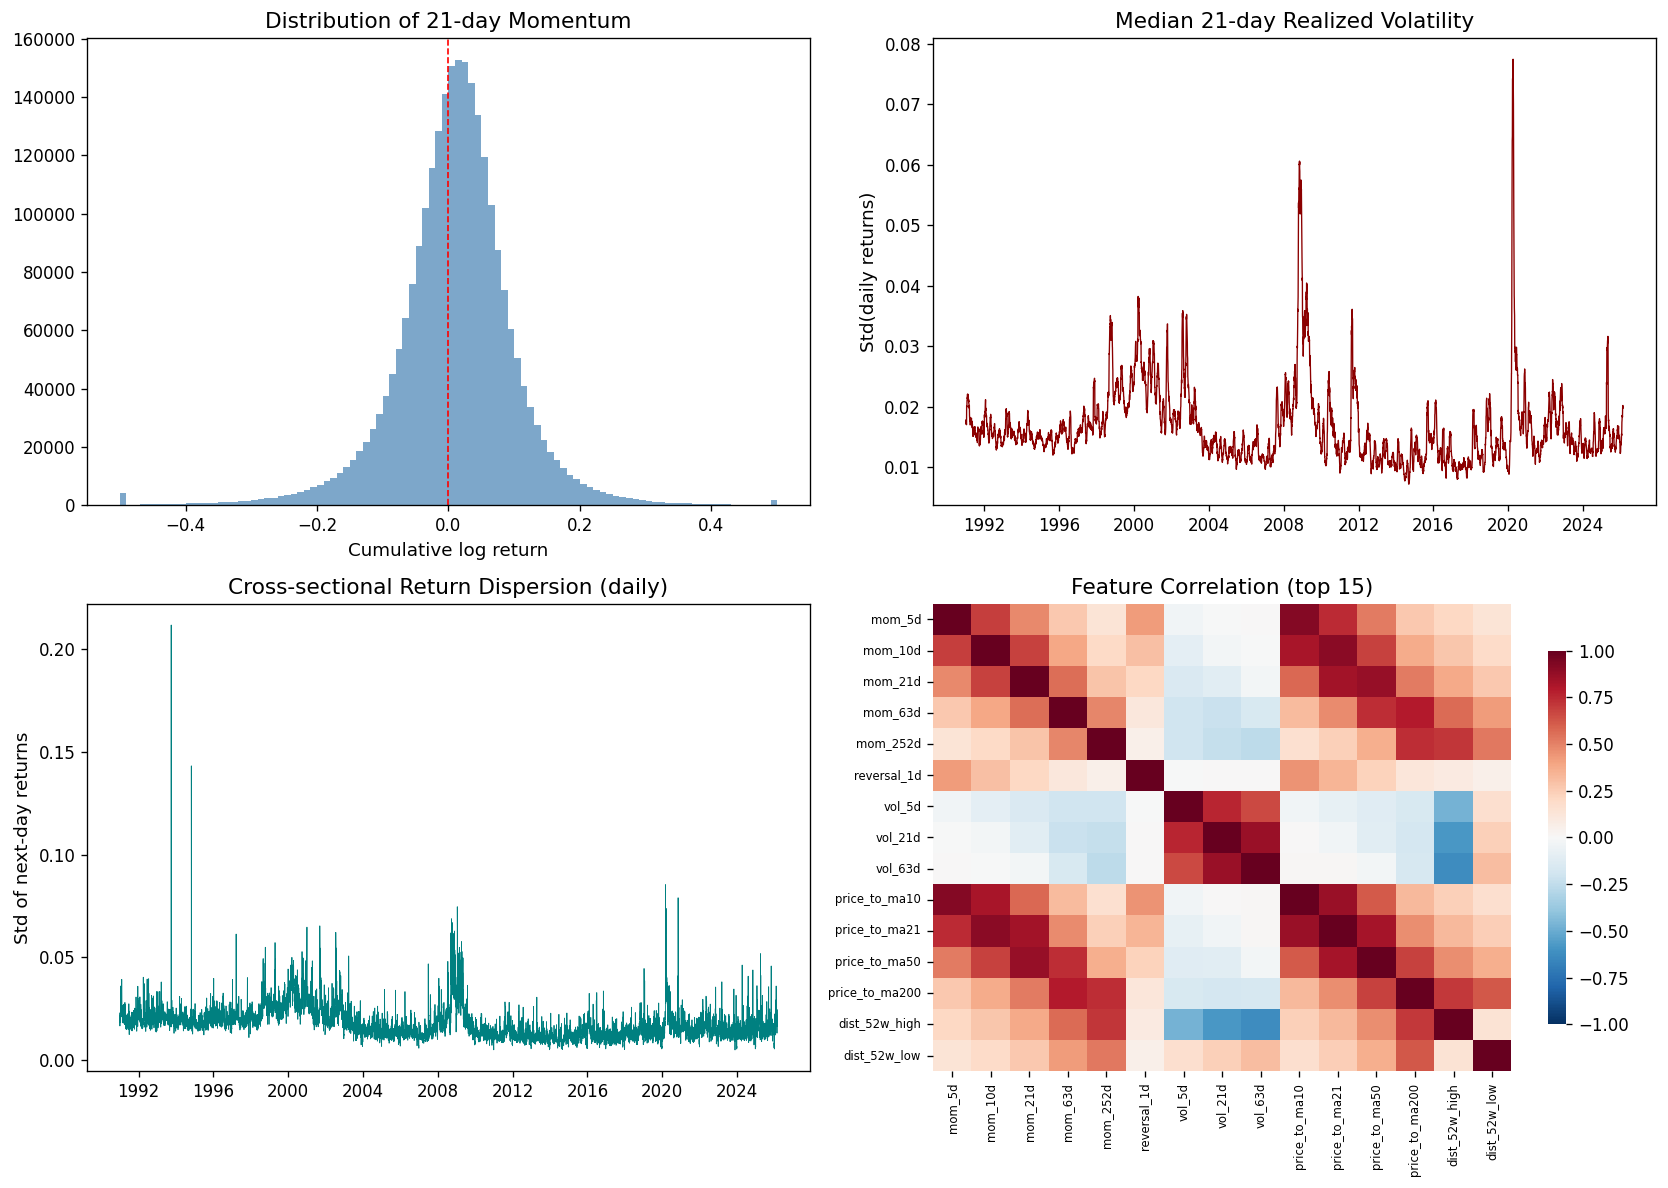


Total observations: 2,542,651
Observations per stock (avg): 8,619


In [3]:
# Feature statistics and visualization

if len(panel_clean) == 0:
    print("ERROR: panel_clean is empty! Check date alignment between prices and macro data.")
    print(f"Panel before cleaning: {len(panel)} rows")
    print(f"NaN counts per feature (sample):")
    for col in feature_cols[:10]:
        print(f"  {col}: {panel[col].isna().sum():,} NaN out of {len(panel):,}")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    sample = panel_clean['mom_21d'].clip(-0.5, 0.5)
    ax.hist(sample, bins=100, alpha=0.7, color='steelblue', edgecolor='none')
    ax.set_title('Distribution of 21-day Momentum')
    ax.set_xlabel('Cumulative log return')
    ax.axvline(0, color='red', lw=1, ls='--')

    ax = axes[0, 1]
    vol_ts = panel_clean.groupby('date')['vol_21d'].median()
    ax.plot(vol_ts.index, vol_ts.values, color='darkred', lw=0.8)
    ax.set_title('Median 21-day Realized Volatility')
    ax.set_ylabel('Std(daily returns)')

    ax = axes[1, 0]
    disp = panel_clean.groupby('date')['ret_1d_fwd'].std()
    ax.plot(disp.index, disp.values, color='teal', lw=0.5)
    ax.set_title('Cross-sectional Return Dispersion (daily)')
    ax.set_ylabel('Std of next-day returns')

    ax = axes[1, 1]
    top_feats = feature_cols[:15]
    corr = panel_clean[top_feats].corr()
    sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.8})
    ax.set_title('Feature Correlation (top 15)')
    ax.tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

    print(f"\nTotal observations: {len(panel_clean):,}")
    print(f"Observations per stock (avg): {len(panel_clean) // panel_clean['stock'].nunique():,}")

## PART 3: Model Horse Race

Daily

In [4]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# Target: daily (1-day) forward return
TARGET = 'ret_1d_fwd'
print(f"Target variable: {TARGET}")

# Drop rows where target is NaN
panel_model = panel_clean.dropna(subset=[TARGET]).copy()
print(f"Panel after dropping NaN target: {panel_model.shape}")

# Temporal splits
train_mask = panel_model['date'] < '2020-01-01'    # 2000–2019 (~20 лет)
val_mask   = (panel_model['date'] >= '2020-01-01') & (panel_model['date'] < '2023-01-01')  # 3 года
test_mask  = panel_model['date'] >= '2023-01-01'   # 2023–2026 (~3 года)

X_train = panel_model.loc[train_mask, feature_cols].values
y_train = panel_model.loc[train_mask, TARGET].values
X_val   = panel_model.loc[val_mask, feature_cols].values
y_val   = panel_model.loc[val_mask, TARGET].values
X_test  = panel_model.loc[test_mask, feature_cols].values
y_test  = panel_model.loc[test_mask, TARGET].values

print(f"Train: {X_train.shape[0]:,} obs ({panel_model.loc[train_mask, 'date'].min().date()} to {panel_model.loc[train_mask, 'date'].max().date()})")
print(f"Val:   {X_val.shape[0]:,} obs")
print(f"Test:  {X_test.shape[0]:,} obs")

# Standardize
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

for arr in [X_train_s, X_val_s, X_test_s]:
    arr[~np.isfinite(arr)] = 0

Target variable: ret_1d_fwd
Panel after dropping NaN target: (2542651, 39)
Train: 2,087,466 obs (1990-12-31 to 2019-12-31)
Val:   223,020 obs
Test:  232,165 obs


In [5]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import torch
import torch.nn as nn
from skorch import NeuralNetRegressor
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit

# Auto-detect GPU
if torch.cuda.is_available():
    TORCH_DEVICE = 'cuda:0'
    XGB_DEVICE   = 'cuda:0'
    CB_TASK_TYPE  = 'GPU'
    CB_DEVICES    = '0'
else:
    TORCH_DEVICE = 'cpu'
    XGB_DEVICE   = 'cpu'
    CB_TASK_TYPE  = 'CPU'
    CB_DEVICES    = None

# GPU Neural Net helpers
class NN1_Module(nn.Module):
    def __init__(self, input_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, X):
        return self.net(X.float()).squeeze(-1)

class NN3_Module(nn.Module):
    def __init__(self, input_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),        nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, X):
        return self.net(X.float()).squeeze(-1)

input_dim = X_train_s.shape[1]

# CatBoost kwargs (subsample only valid with Bernoulli bootstrap)
catboost_params = dict(
    iterations=300, depth=4, learning_rate=0.01,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli', subsample=0.8,
    min_data_in_leaf=200, random_seed=42,
    verbose=0,
    task_type='CPU',
)
if CB_DEVICES is not None:
    catboost_params['devices'] = CB_DEVICES

models_daily = {
    'OLS':          LinearRegression(),
    'Ridge':        Ridge(alpha=10.0),
    'LASSO':        Lasso(alpha=0.001, max_iter=5000),
    'ElasticNet':   ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=200,
                                          n_jobs=-1, random_state=42),
    'XGBoost':      XGBRegressor(n_estimators=300, max_depth=3,
                                  learning_rate=0.01, min_child_weight=200,
                                  subsample=0.8, random_state=42,
                                  device=XGB_DEVICE),
    'ExtraTrees':   ExtraTreesRegressor(n_estimators=300, max_depth=4, min_samples_leaf=200,
                                         n_jobs=-1, random_state=42),
    'CatBoost':     CatBoostRegressor(**catboost_params),
    'NN1':          NeuralNetRegressor(
                        NN1_Module,
                        module__input_dim=input_dim,
                        max_epochs=500, lr=0.0005, batch_size=256,
                        optimizer=torch.optim.Adam,
                        optimizer__weight_decay=0.01,
                        device=TORCH_DEVICE,
                        callbacks=[EarlyStopping(patience=10, monitor='valid_loss')],
                        train_split=ValidSplit(cv=0.2, random_state=42),  # <-- исправлено
                        verbose=0,
                    ),
    'NN3':          NeuralNetRegressor(
                        NN3_Module,
                        module__input_dim=input_dim,
                        max_epochs=500, lr=0.0005, batch_size=256,
                        optimizer=torch.optim.Adam,
                        optimizer__weight_decay=0.01,
                        device=TORCH_DEVICE,
                        callbacks=[EarlyStopping(patience=10, monitor='valid_loss')],
                        train_split=ValidSplit(cv=0.2, random_state=42),  # <-- исправлено
                        verbose=0,
                    ),
}

# OOS R^2 per Gu, Kelly & Xiu (2020)
def oos_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum(y_true**2)
    return 1 - ss_res / ss_tot

# Train and evaluate
results_daily = {}
predictions_test_daily = {}

for name, model in models_daily.items():
    print(f"Training {name}...", end=" ", flush=True)
    try:
        if name in ('NN1', 'NN3'):
            model.fit(X_train_s.astype(np.float32), y_train.astype(np.float32))
            pred_val  = model.predict(X_val_s.astype(np.float32))
            pred_test = model.predict(X_test_s.astype(np.float32))
        else:
            model.fit(X_train_s, y_train)
            pred_val  = model.predict(X_val_s)
            pred_test = model.predict(X_test_s)

        results_daily[name] = {
            'val_R2_oos':   oos_r2(y_val, pred_val),
            'test_R2_oos':  oos_r2(y_test, pred_test),
            'val_RMSE':     np.sqrt(mean_squared_error(y_val, pred_val)),
            'test_RMSE':    np.sqrt(mean_squared_error(y_test, pred_test)),
            'val_R2_std':   r2_score(y_val, pred_val),
            'test_R2_std':  r2_score(y_test, pred_test),
        }
        predictions_test_daily[name] = pred_test
        print(f"OOS R2(test)={results_daily[name]['test_R2_oos']:.4f}")
    except Exception as e:
        print(f"FAILED: {e}")

results_daily_df = pd.DataFrame(results_daily).T
print("\n" + results_daily_df.to_string())

Training OLS... OOS R2(test)=-0.0006
Training Ridge... OOS R2(test)=-0.0006
Training LASSO... OOS R2(test)=0.0006
Training ElasticNet... OOS R2(test)=0.0009
Training RandomForest... OOS R2(test)=-0.0038
Training XGBoost... OOS R2(test)=-0.0182
Training ExtraTrees... OOS R2(test)=-0.0014
Training CatBoost... OOS R2(test)=-0.0030
Training NN1... OOS R2(test)=0.0002
Training NN3... OOS R2(test)=0.0002

              val_R2_oos  test_R2_oos  val_RMSE  test_RMSE  val_R2_std  test_R2_std
OLS            -0.000069    -0.000574  0.025379   0.018765   -0.000220    -0.001144
Ridge          -0.000069    -0.000573  0.025379   0.018765   -0.000220    -0.001143
LASSO           0.000097     0.000562  0.025377   0.018755   -0.000054    -0.000007
ElasticNet      0.000842     0.000909  0.025368   0.018752    0.000692     0.000340
RandomForest   -0.030507    -0.003807  0.025763   0.018796   -0.030663    -0.004379
XGBoost        -0.006375    -0.018214  0.025459   0.018930   -0.006527    -0.018794
ExtraTree

## Deep Learning Architectures for Asset Pricing

We extend the horse race with four state-of-the-art deep learning architectures, all implemented in **pure PyTorch** and trained on **GPU** (`TORCH_DEVICE`):

| Model | Reference | Key Idea |
|-------|-----------|----------|
| **Transformer** | Kelly, Kuznetsov, Malamud & Xu (2025), *"Artificial Intelligence Asset Pricing Models"*, NBER WP 33351 | Self-attention over feature tokens enables cross-asset information sharing within the SDF |
| **CNN** | Jiang, Kelly & Xiu (2023), *"(Re-)Imag(in)ing Price Trends"*, Journal of Finance, 78(6), 3193–3249 | Convolutional filters detect local patterns in the cross-section of stock characteristics |
| **GNN** | Korangi, Mues & Bravo (2024), *"Large-scale Portfolio Optimisation using GAT"*, arXiv:2407.15532; Uddin et al. (2023), *"Attention-based Dynamic GNN for Asset Pricing"*, GFJ 58 | Graph convolutions propagate information across correlated stocks |

All models are trained end-to-end with MSE loss on the same train/val/test splits.
Mixed-precision (`torch.cuda.amp`) is used when a CUDA device is available.
The GNN uses a return-correlation adjacency matrix built from the training period.

In [ ]:
# ============================================================
# Deep Learning Model Definitions (pure PyTorch, GPU)
# Transformer / Mamba (SSM) / CNN / GNN
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import math, gc
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
import traceback
from tqdm.auto import tqdm

# Reuse TORCH_DEVICE from cell 7 (e.g. 'cuda:0' or 'cpu')
DEVICE = torch.device(TORCH_DEVICE)
USE_AMP = DEVICE.type == 'cuda'
print(f"DL device: {DEVICE}  |  AMP (mixed-precision): {USE_AMP}")

# ----------------------------------------------------------
# TRANSFORMER — Kelly, Kuznetsov, Malamud & Xu (2025)
# ----------------------------------------------------------
class TransformerPricer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.tok_embed = nn.Linear(1, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, input_dim, d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 2,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 32), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(32, 1))

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.tok_embed(x) + self.pos_embed
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.head(x).squeeze(-1)

# ----------------------------------------------------------
# CNN — Jiang, Kelly & Xiu (2023)
# ----------------------------------------------------------
class CNNPricer(nn.Module):
    def __init__(self, input_dim, dropout=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1,  32, 3, padding=1), nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Conv1d(32, 64, 3, padding=1), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.AdaptiveAvgPool1d(16),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(8))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1))

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        return self.head(x).squeeze(-1)

# ----------------------------------------------------------
# GNN — Korangi et al. (2024), Uddin et al. (2023)
# ----------------------------------------------------------
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=True)
    def forward(self, X, A_norm):
        return F.relu(self.W(A_norm @ X))

class GNNPricer(nn.Module):
    def __init__(self, in_dim, hidden=64, dropout=0.1):
        super().__init__()
        self.gcn1 = GCNLayer(in_dim, hidden)
        self.gcn2 = GCNLayer(hidden, hidden)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1))
    def forward(self, X, A_norm):
        h = self.drop(self.gcn1(X, A_norm))
        h = self.drop(self.gcn2(h, A_norm))
        return self.head(h).squeeze(-1)

# ==============================================================
# Training helpers (pure PyTorch, GPU, AMP, tqdm)
# ==============================================================
def train_pytorch_model(model, X_tr, y_tr, X_vl, y_vl,
                        epochs=200, batch_size=512, lr=5e-4, wd=1e-3,
                        patience=15, verbose_name='Model'):
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.01)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    ds = TensorDataset(torch.from_numpy(X_tr).float(),
                       torch.from_numpy(y_tr).float())
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True,
                    drop_last=True, pin_memory=(DEVICE.type == 'cuda'), num_workers=0)

    X_vl_t = torch.from_numpy(X_vl).float().to(DEVICE)
    y_vl_t = torch.from_numpy(y_vl).float().to(DEVICE)

    best_loss, best_state, wait = float('inf'), None, 0
    pbar = tqdm(range(epochs), desc=f'  {verbose_name}', leave=True)
    for ep in pbar:
        model.train()
        train_loss_sum, train_n = 0.0, 0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                loss = F.mse_loss(model(xb), yb)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            train_loss_sum += loss.item() * len(xb)
            train_n += len(xb)
        sched.step()

        model.eval()
        with torch.no_grad():
            vl_preds = []
            for vi in range(0, len(X_vl_t), batch_size):
                xvb = X_vl_t[vi:vi+batch_size]
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    vl_preds.append(model(xvb))
            val_loss = F.mse_loss(torch.cat(vl_preds), y_vl_t).item()

        pbar.set_postfix(train=f'{train_loss_sum/train_n:.6f}',
                         val=f'{val_loss:.6f}',
                         best=f'{best_loss:.6f}',
                         wait=f'{wait}/{patience}')
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    pbar.close()
    model.load_state_dict(best_state)
    model = model.to(DEVICE).eval()
    print(f"  {verbose_name}: stopped ep {ep+1}/{epochs}, best_val_loss={best_loss:.6f}")
    return model


@torch.no_grad()
def predict_pytorch(model, X, batch_size=4096):
    model.eval()
    X_t = torch.from_numpy(X).float()
    preds = []
    for i in range(0, len(X_t), batch_size):
        xb = X_t[i:i+batch_size].to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            preds.append(model(xb).float().cpu())
    return torch.cat(preds).numpy()

# ==============================================================
# GNN helpers
# ==============================================================
def build_adjacency(panel_train, feature_cols, stocks):
    ret_pivot = panel_train.pivot_table(index='date', columns='stock', values='return')
    ret_pivot = ret_pivot.reindex(columns=stocks).dropna(axis=0, how='any')
    corr = ret_pivot.corr().values.copy()
    np.fill_diagonal(corr, 0)
    threshold = np.percentile(np.abs(corr), 75)
    A = (np.abs(corr) > threshold).astype(np.float32)
    np.fill_diagonal(A, 1.0)
    d_inv_sqrt = 1.0 / np.sqrt(np.maximum(A.sum(axis=1), 1e-8))
    A_norm = A * d_inv_sqrt[:, None] * d_inv_sqrt[None, :]
    return torch.from_numpy(A_norm).float().to(DEVICE)


def train_gnn_model(gnn, panel_tr, panel_vl, feature_cols, stocks,
                    A_norm_gpu, target_col, epochs=80, lr=5e-4, patience=10):
    gnn = gnn.to(DEVICE)
    opt    = torch.optim.AdamW(gnn.parameters(), lr=lr, weight_decay=1e-3)
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.01)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    stock_to_idx = {s: i for i, s in enumerate(stocks)}
    N, F_dim = len(stocks), len(feature_cols)

    def _precompute_batches(panel_sub):
        batches = []
        for date, grp in panel_sub.groupby('date'):
            if len(grp) < N * 0.3:
                continue
            X_np = np.zeros((N, F_dim), dtype=np.float32)
            y_np = np.zeros(N, dtype=np.float32)
            mask  = np.zeros(N, dtype=np.bool_)
            for _, row in grp.iterrows():
                idx = stock_to_idx.get(row['stock'])
                if idx is not None:
                    X_np[idx] = row[feature_cols].values.astype(np.float32)
                    y_np[idx] = row[target_col]
                    mask[idx] = True
            if mask.sum() > 5:
                batches.append((
                    torch.from_numpy(X_np).to(DEVICE),
                    torch.from_numpy(y_np).to(DEVICE),
                    torch.from_numpy(mask).to(DEVICE)))
        return batches

    print(f"  GNN: precomputing date batches...", end=" ", flush=True)
    train_batches = _precompute_batches(panel_tr)
    val_batches   = _precompute_batches(panel_vl)
    print(f"{len(train_batches)} train / {len(val_batches)} val dates")

    best_loss, best_state, wait = float('inf'), None, 0
    pbar = tqdm(range(epochs), desc='  GNN', leave=True)
    for ep in pbar:
        gnn.train()
        ep_loss_sum, ep_n = 0.0, 0
        perm = torch.randperm(len(train_batches))
        for bi in perm:
            X_g, y_g, m = train_batches[bi]
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                pred = gnn(X_g, A_norm_gpu)
                loss = F.mse_loss(pred[m], y_g[m])
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(gnn.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            ep_loss_sum += loss.item() * m.sum().item()
            ep_n += m.sum().item()
        sched.step()

        gnn.eval()
        vl_sum, vl_cnt = 0.0, 0
        with torch.no_grad(), torch.cuda.amp.autocast(enabled=USE_AMP):
            for X_g, y_g, m in val_batches:
                pred = gnn(X_g, A_norm_gpu)
                vl_sum += F.mse_loss(pred[m], y_g[m]).item() * m.sum().item()
                vl_cnt += m.sum().item()
        vl = vl_sum / max(vl_cnt, 1)

        pbar.set_postfix(train=f'{ep_loss_sum/max(ep_n,1):.6f}',
                         val=f'{vl:.6f}',
                         best=f'{best_loss:.6f}',
                         wait=f'{wait}/{patience}')
        if vl < best_loss:
            best_loss, best_state, wait = vl, {k: v.cpu().clone() for k, v in gnn.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                break

    pbar.close()
    gnn.load_state_dict(best_state)
    gnn = gnn.to(DEVICE).eval()
    print(f"  GNN: stopped ep {ep+1}/{epochs}, best_val_loss={best_loss:.6f}")
    return gnn


@torch.no_grad()
def predict_gnn(gnn, panel_sub, feature_cols, stocks, A_norm_gpu):
    gnn.eval()
    stock_to_idx = {s: i for i, s in enumerate(stocks)}
    N, F_dim = len(stocks), len(feature_cols)
    panel_sub = panel_sub.reset_index(drop=True)
    preds = np.zeros(len(panel_sub), dtype=np.float64)

    for date, grp in panel_sub.groupby('date'):
        X_np = np.zeros((N, F_dim), dtype=np.float32)
        row_map = {}
        for row_idx, row in grp.iterrows():
            sidx = stock_to_idx.get(row['stock'])
            if sidx is not None:
                X_np[sidx] = row[feature_cols].values.astype(np.float32)
                row_map[sidx] = row_idx
        X_g = torch.from_numpy(X_np).to(DEVICE)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            pred_g = gnn(X_g, A_norm_gpu).float().cpu().numpy()
        for sidx, row_idx in row_map.items():
            preds[row_idx] = pred_g[sidx]
    return preds

print("Model classes and GPU training helpers defined.")
print(f"  GPU memory: {torch.cuda.memory_allocated(DEVICE)/1e6:.0f} MB allocated" if DEVICE.type == 'cuda' else "  (CPU mode)")

DL device: cuda:0  |  AMP (mixed-precision): True
Model classes and GPU training helpers defined.
  GPU memory: 17 MB allocated


In [7]:
# Transformer (Kelly, Kuznetsov, Malamud & Xu, 2025; NBER WP 33351)
print("\nTransformer...")
try:
    torch.cuda.empty_cache()
    tf_model = TransformerPricer(input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1)
    tf_model = train_pytorch_model(tf_model, X_train_s, y_train, X_val_s, y_val,
                                   epochs=200, batch_size=512, lr=5e-4, verbose_name='Transformer')
    p_val  = predict_pytorch(tf_model, X_val_s)
    p_test = predict_pytorch(tf_model, X_test_s)
    results_daily['Transformer'] = {
        'val_R2_oos': oos_r2(y_val, p_val), 'test_R2_oos': oos_r2(y_test, p_test),
        'val_RMSE': np.sqrt(mean_squared_error(y_val, p_val)),
        'test_RMSE': np.sqrt(mean_squared_error(y_test, p_test)),
        'val_R2_std': r2_score(y_val, p_val), 'test_R2_std': r2_score(y_test, p_test)}
    predictions_test_daily['Transformer'] = p_test
    print(f"  OOS R2 = {results_daily['Transformer']['test_R2_oos']:.4f}")
except Exception as e:
    print(f"  FAILED: {e}")
    traceback.print_exc()



Transformer...


  Transformer:   0%|          | 0/200 [00:00<?, ?it/s]

  Transformer: stopped ep 24/200, best_val_loss=0.000641
  OOS R2 = -0.0141


In [9]:
# CNN (Jiang, Kelly & Xiu, 2023; Journal of Finance)
print("\nCNN...")
try:
    torch.cuda.empty_cache()
    cnn_model = CNNPricer(input_dim, dropout=0.1)
    cnn_model = train_pytorch_model(cnn_model, X_train_s, y_train, X_val_s, y_val,
                                    epochs=200, batch_size=512, lr=5e-4, verbose_name='CNN')
    p_val  = predict_pytorch(cnn_model, X_val_s)
    p_test = predict_pytorch(cnn_model, X_test_s)
    results_daily['CNN'] = {
        'val_R2_oos': oos_r2(y_val, p_val), 'test_R2_oos': oos_r2(y_test, p_test),
        'val_RMSE': np.sqrt(mean_squared_error(y_val, p_val)),
        'test_RMSE': np.sqrt(mean_squared_error(y_test, p_test)),
        'val_R2_std': r2_score(y_val, p_val), 'test_R2_std': r2_score(y_test, p_test)}
    predictions_test_daily['CNN'] = p_test
    print(f"  OOS R2 = {results_daily['CNN']['test_R2_oos']:.4f}")
except Exception as e:
    print(f"  FAILED: {e}")
    traceback.print_exc()


CNN...


  CNN:   0%|          | 0/200 [00:00<?, ?it/s]

  CNN: stopped ep 24/200, best_val_loss=0.000632
  OOS R2 = 0.0029


In [10]:
# GNN (Korangi et al. 2024; Uddin et al. 2023)
print("\nGNN...")
try:
    torch.cuda.empty_cache()
    stocks_list = panel_model['stock'].unique().tolist()

    # Build standardized panel copies for GNN (writeable copies)
    panel_tr = panel_model.loc[train_mask].copy()
    panel_vl = panel_model.loc[val_mask].copy()
    panel_te = panel_model.loc[test_mask].copy()
    X_train_w = np.array(X_train_s, copy=True)
    X_val_w   = np.array(X_val_s, copy=True)
    X_test_w  = np.array(X_test_s, copy=True)
    for ci, cn in enumerate(feature_cols):
        panel_tr[cn] = X_train_w[:, ci]
        panel_vl[cn] = X_val_w[:, ci]
        panel_te[cn] = X_test_w[:, ci]

    A_norm_gpu = build_adjacency(panel_model.loc[train_mask], feature_cols, stocks_list)
    gnn_model  = GNNPricer(len(feature_cols), hidden=64, dropout=0.1)
    gnn_model  = train_gnn_model(gnn_model, panel_tr, panel_vl, feature_cols, stocks_list,
                                  A_norm_gpu, target_col=TARGET, epochs=80, lr=5e-4, patience=10)
    p_val  = predict_gnn(gnn_model, panel_vl, feature_cols, stocks_list, A_norm_gpu)
    p_test = predict_gnn(gnn_model, panel_te, feature_cols, stocks_list, A_norm_gpu)
    results_daily['GNN'] = {
        'val_R2_oos': oos_r2(y_val, p_val), 'test_R2_oos': oos_r2(y_test, p_test),
        'val_RMSE': np.sqrt(mean_squared_error(y_val, p_val)),
        'test_RMSE': np.sqrt(mean_squared_error(y_test, p_test)),
        'val_R2_std': r2_score(y_val, p_val), 'test_R2_std': r2_score(y_test, p_test)}
    predictions_test_daily['GNN'] = p_test
    print(f"  OOS R2 = {results_daily['GNN']['test_R2_oos']:.4f}")
except Exception as e:
    print(f"  GNN FAILED: {e}")
    traceback.print_exc()


GNN...
  GNN: precomputing date batches... 7307 train / 756 val dates


  GNN:   0%|          | 0/80 [00:00<?, ?it/s]

  GNN: stopped ep 19/80, best_val_loss=0.000644
  OOS R2 = 0.0005


In [11]:
# Rebuild DataFrame with new models included
results_daily_df = pd.DataFrame(results_daily).T
print("\nUpdated daily results table:")
print(results_daily_df.to_string())

# Free GPU cache
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU memory after cleanup: {torch.cuda.memory_allocated(DEVICE)/1e6:.0f} MB")


Updated daily results table:
              val_R2_oos  test_R2_oos  val_RMSE  test_RMSE  val_R2_std  test_R2_std
OLS            -0.000069    -0.000574  0.025379   0.018765   -0.000220    -0.001144
Ridge          -0.000069    -0.000573  0.025379   0.018765   -0.000220    -0.001143
LASSO           0.000097     0.000562  0.025377   0.018755   -0.000054    -0.000007
ElasticNet      0.000842     0.000909  0.025368   0.018752    0.000692     0.000340
RandomForest   -0.030507    -0.003807  0.025763   0.018796   -0.030663    -0.004379
XGBoost        -0.006375    -0.018214  0.025459   0.018930   -0.006527    -0.018794
ExtraTrees     -0.001712    -0.001355  0.025400   0.018773   -0.001863    -0.001925
CatBoost        0.003159    -0.003044  0.025338   0.018789    0.003008    -0.003616
NN1            -0.000223     0.000211  0.025381   0.018758   -0.000374    -0.000358
NN3            -0.000223     0.000211  0.025381   0.018758   -0.000374    -0.000358
Transformer     0.004199    -0.014073  0.02532

In [12]:
# Portfolio: daily target, daily rebalancing
def compute_portfolio_sharpe_daily(panel_subset, predictions, target_col='ret_1d_fwd'):
    df = panel_subset[['date', 'stock', target_col]].copy()
    df['pred'] = predictions

    daily_returns = []
    for date, grp in df.groupby('date'):
        n = len(grp)
        q = max(n // 5, 1)
        sorted_grp = grp.sort_values('pred')
        short_ret = sorted_grp.head(q)[target_col].mean()
        long_ret  = sorted_grp.tail(q)[target_col].mean()
        daily_returns.append(long_ret - short_ret)

    daily_returns = np.array(daily_returns)
    daily_returns = daily_returns[np.isfinite(daily_returns)]
    if len(daily_returns) == 0:
        return 0.0, np.array([])
    sharpe = np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252)
    return sharpe, daily_returns

test_panel_daily = panel_model.loc[test_mask].copy()
portfolio_results_daily = {}

print("Portfolio Sharpe Ratios (annualized, L/S quintile, DAILY):\n")
for name, pred in predictions_test_daily.items():
    sharpe, d_rets = compute_portfolio_sharpe_daily(test_panel_daily, pred, target_col='ret_1d_fwd')
    cum_ret = np.cumsum(d_rets)
    portfolio_results_daily[name] = {
        'Sharpe': sharpe,
        'Ann_Return': np.mean(d_rets) * 252,
        'Ann_Vol': np.std(d_rets) * np.sqrt(252),
        'daily_rets': d_rets,
        'cum_rets': cum_ret,
    }
    print(f"  {name:15s}: Sharpe={sharpe:+.2f}  Ann.Ret={portfolio_results_daily[name]['Ann_Return']:+.1%}  Ann.Vol={portfolio_results_daily[name]['Ann_Vol']:.1%}")

portfolio_daily_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk not in ('daily_rets', 'cum_rets')}
                                    for k, v in portfolio_results_daily.items()}).T
print("\n" + portfolio_daily_df.to_string())

Portfolio Sharpe Ratios (annualized, L/S quintile, DAILY):

  OLS            : Sharpe=+0.41  Ann.Ret=+5.7%  Ann.Vol=13.9%
  Ridge          : Sharpe=+0.41  Ann.Ret=+5.7%  Ann.Vol=13.9%
  LASSO          : Sharpe=-0.48  Ann.Ret=-6.4%  Ann.Vol=13.3%
  ElasticNet     : Sharpe=+0.22  Ann.Ret=+3.3%  Ann.Vol=15.0%
  RandomForest   : Sharpe=-0.48  Ann.Ret=-5.2%  Ann.Vol=10.7%
  XGBoost        : Sharpe=+0.18  Ann.Ret=+2.5%  Ann.Vol=14.0%
  ExtraTrees     : Sharpe=+0.26  Ann.Ret=+4.0%  Ann.Vol=15.7%
  CatBoost       : Sharpe=+0.29  Ann.Ret=+4.1%  Ann.Vol=14.4%
  NN1            : Sharpe=-0.21  Ann.Ret=-3.0%  Ann.Vol=14.3%
  NN3            : Sharpe=-0.48  Ann.Ret=-6.4%  Ann.Vol=13.3%
  Transformer    : Sharpe=+0.61  Ann.Ret=+8.6%  Ann.Vol=14.0%
  CNN            : Sharpe=-0.15  Ann.Ret=-2.0%  Ann.Vol=13.6%
  GNN            : Sharpe=-0.48  Ann.Ret=-6.4%  Ann.Vol=13.3%

                Sharpe  Ann_Return   Ann_Vol
OLS           0.412873    0.057243  0.138646
Ridge         0.411952    0.057116  0.13864

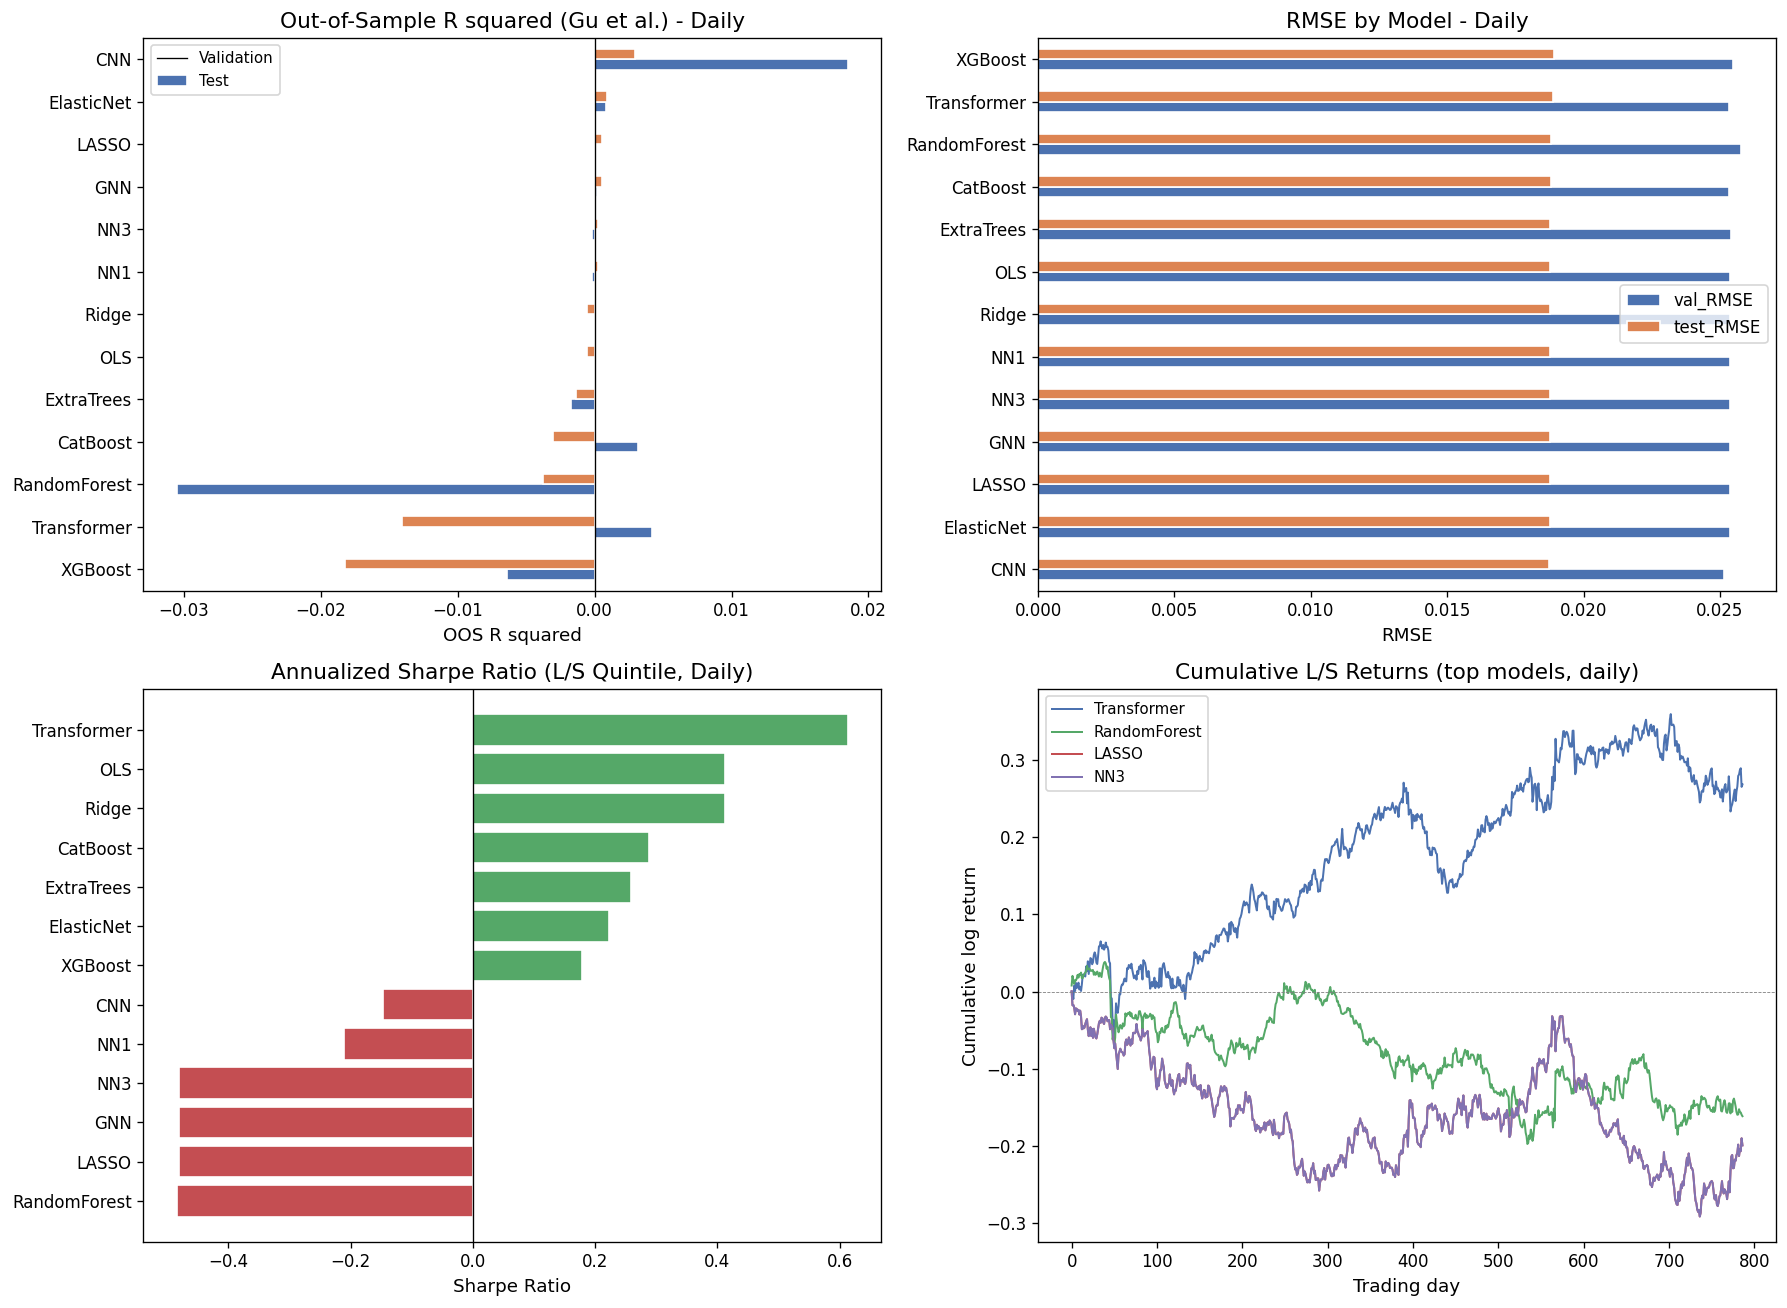

Daily horse race complete.


In [13]:
# Visualization: Model comparison (Daily)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

ax = axes[0, 0]
r2_data = results_daily_df[['val_R2_oos', 'test_R2_oos']].sort_values('test_R2_oos', ascending=True)
r2_data.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Out-of-Sample R squared (Gu et al.) - Daily')
ax.set_xlabel('OOS R squared')
ax.legend(['Validation', 'Test'], fontsize=9)

ax = axes[0, 1]
rmse_data = results_daily_df[['val_RMSE', 'test_RMSE']].sort_values('test_RMSE', ascending=True)
rmse_data.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
ax.set_title('RMSE by Model - Daily')
ax.set_xlabel('RMSE')

ax = axes[1, 0]
sharpe_vals = portfolio_daily_df['Sharpe'].sort_values()
colors = ['#55A868' if v > 0 else '#C44E52' for v in sharpe_vals]
ax.barh(sharpe_vals.index, sharpe_vals.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Annualized Sharpe Ratio (L/S Quintile, Daily)')
ax.set_xlabel('Sharpe Ratio')

ax = axes[1, 1]
top_models = portfolio_daily_df['Sharpe'].abs().nlargest(4).index
colors_line = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
for i, name in enumerate(top_models):
    cum = portfolio_results_daily[name]['cum_rets']
    ax.plot(range(len(cum)), cum, label=name, lw=1.2, color=colors_line[i % len(colors_line)])
ax.set_title('Cumulative L/S Returns (top models, daily)')
ax.set_ylabel('Cumulative log return')
ax.set_xlabel('Trading day')
ax.legend(fontsize=9)
ax.axhline(0, color='grey', lw=0.5, ls='--')

plt.tight_layout()
plt.show()
print("Daily horse race complete.")

Weekly

In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# Target: weekly (5-day) forward return (stronger signal than daily)
TARGET = 'ret_5d_fwd'
print(f"Target variable: {TARGET}")

# Drop rows where target is NaN
panel_model = panel_clean.dropna(subset=[TARGET]).copy()
print(f"Panel after dropping NaN target: {panel_model.shape}")

# Temporal splits
train_mask = panel_model['date'] < '2020-01-01'    # 2000–2019 (~20 лет)
val_mask   = (panel_model['date'] >= '2020-01-01') & (panel_model['date'] < '2023-01-01')  # 3 года
test_mask  = panel_model['date'] >= '2023-01-01'   # 2023–2026 (~3 года)

X_train = panel_model.loc[train_mask, feature_cols].values
y_train = panel_model.loc[train_mask, TARGET].values
X_val   = panel_model.loc[val_mask, feature_cols].values
y_val   = panel_model.loc[val_mask, TARGET].values
X_test  = panel_model.loc[test_mask, feature_cols].values
y_test  = panel_model.loc[test_mask, TARGET].values

print(f"Train: {X_train.shape[0]:,} obs ({panel_model.loc[train_mask, 'date'].min().date()} to {panel_model.loc[train_mask, 'date'].max().date()})")
print(f"Val:   {X_val.shape[0]:,} obs")
print(f"Test:  {X_test.shape[0]:,} obs")

# Standardize
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

for arr in [X_train_s, X_val_s, X_test_s]:
    arr[~np.isfinite(arr)] = 0


Target variable: ret_5d_fwd
Panel after dropping NaN target: (2541471, 39)
Train: 2,087,466 obs (1990-12-31 to 2019-12-31)
Val:   223,020 obs
Test:  230,985 obs


In [15]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import torch
import torch.nn as nn
from skorch import NeuralNetRegressor
from skorch.callbacks import EarlyStopping
from skorch.dataset import ValidSplit

# Auto-detect GPU
if torch.cuda.is_available():
    TORCH_DEVICE = 'cuda:0'
    XGB_DEVICE   = 'cuda:0'
    CB_TASK_TYPE  = 'GPU'
    CB_DEVICES    = '0'
else:
    TORCH_DEVICE = 'cpu'
    XGB_DEVICE   = 'cpu'
    CB_TASK_TYPE  = 'CPU'
    CB_DEVICES    = None

# Neural Net helpers
class NN1_Module(nn.Module):
    def __init__(self, input_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, X):
        return self.net(X.float()).squeeze(-1)

class NN3_Module(nn.Module):
    def __init__(self, input_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32),        nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, 1),
        )
    def forward(self, X):
        return self.net(X.float()).squeeze(-1)

input_dim = X_train_s.shape[1]

# CatBoost kwargs
catboost_params = dict(
    iterations=300, depth=4, learning_rate=0.01,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli', subsample=0.8,
    min_data_in_leaf=200, random_seed=42,
    verbose=0,
    task_type='CPU',
)
if CB_DEVICES is not None:
    catboost_params['devices'] = CB_DEVICES

models_weekly = {
    'OLS':          LinearRegression(),
    'Ridge':        Ridge(alpha=10.0),
    'LASSO':        Lasso(alpha=0.001, max_iter=5000),
    'ElasticNet':   ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=4, min_samples_leaf=200,
                                      n_jobs=-1, random_state=42),
    'XGBoost':      XGBRegressor(n_estimators=300, max_depth=3,
                                  learning_rate=0.01, min_child_weight=200,
                                  subsample=0.8, random_state=42,
                                  device=XGB_DEVICE),
    'ExtraTrees':   ExtraTreesRegressor(n_estimators=100, max_depth=4, min_samples_leaf=200,
                                         n_jobs=-1, random_state=42),
    'CatBoost':     CatBoostRegressor(**catboost_params),
    'NN1':          NeuralNetRegressor(
                        NN1_Module,
                        module__input_dim=input_dim,
                        max_epochs=500, lr=0.0005, batch_size=256,
                        optimizer=torch.optim.Adam,
                        optimizer__weight_decay=0.01,
                        device=TORCH_DEVICE,
                        callbacks=[EarlyStopping(patience=10, monitor='valid_loss')],
                        train_split=ValidSplit(cv=0.2, random_state=42),
                        verbose=0,
                    ),
    'NN3':          NeuralNetRegressor(
                        NN3_Module,
                        module__input_dim=input_dim,
                        max_epochs=500, lr=0.0005, batch_size=256,
                        optimizer=torch.optim.Adam,
                        optimizer__weight_decay=0.01,
                        device=TORCH_DEVICE,
                        callbacks=[EarlyStopping(patience=10, monitor='valid_loss')],
                        train_split=ValidSplit(cv=0.2, random_state=42),
                        verbose=0,
                    ),
}

# OOS R^2 per Gu, Kelly & Xiu (2020)
def oos_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum(y_true**2)
    return 1 - ss_res / ss_tot

# Train and evaluate
results_weekly = {}
predictions_test_weekly = {}

for name, model in models_weekly.items():
    print(f"Training {name}...", end=" ", flush=True)
    try:
        if name in ('NN1', 'NN3'):
            model.fit(X_train_s.astype(np.float32), y_train.astype(np.float32))
            pred_val  = model.predict(X_val_s.astype(np.float32))
            pred_test = model.predict(X_test_s.astype(np.float32))
        else:
            model.fit(X_train_s, y_train)
            pred_val  = model.predict(X_val_s)
            pred_test = model.predict(X_test_s)

        results_weekly[name] = {
            'val_R2_oos':   oos_r2(y_val, pred_val),
            'test_R2_oos':  oos_r2(y_test, pred_test),
            'val_RMSE':     np.sqrt(mean_squared_error(y_val, pred_val)),
            'test_RMSE':    np.sqrt(mean_squared_error(y_test, pred_test)),
            'val_R2_std':   r2_score(y_val, pred_val),
            'test_R2_std':  r2_score(y_test, pred_test),
        }
        predictions_test_weekly[name] = pred_test
        print(f"OOS R2(test)={results_weekly[name]['test_R2_oos']:.4f}")
    except Exception as e:
        print(f"FAILED: {e}")

results_weekly_df = pd.DataFrame(results_weekly).T
print("\n" + results_weekly_df.to_string())

Training OLS... OOS R2(test)=-0.0023
Training Ridge... OOS R2(test)=-0.0022
Training LASSO... OOS R2(test)=0.0029
Training ElasticNet... OOS R2(test)=0.0025
Training RandomForest... OOS R2(test)=-0.0091
Training XGBoost... OOS R2(test)=0.0027
Training ExtraTrees... OOS R2(test)=0.0027
Training CatBoost... OOS R2(test)=0.0030
Training NN1... OOS R2(test)=0.0009
Training NN3... OOS R2(test)=0.0009

              val_R2_oos  test_R2_oos  val_RMSE  test_RMSE  val_R2_std  test_R2_std
OLS             0.005960    -0.002253  0.054668   0.041080    0.005033    -0.005059
Ridge           0.005960    -0.002249  0.054668   0.041080    0.005033    -0.005054
LASSO           0.001467     0.002923  0.054791   0.040974    0.000536     0.000132
ElasticNet      0.001629     0.002544  0.054787   0.040982    0.000699    -0.000248
RandomForest   -0.056550    -0.009061  0.056361   0.041220   -0.057535    -0.011885
XGBoost         0.002673     0.002656  0.054758   0.040980    0.001743    -0.000135
ExtraTrees  

In [16]:
# ============================================================
# Train Deep Learning models (WEEKLY target) — GPU
# ============================================================
print("\n" + "="*70)
print("TRAINING DEEP ARCHITECTURES (WEEKLY) on", DEVICE)
print("="*70)

input_dim = X_train_s.shape[1]
TARGET = 'ret_5d_fwd'

# Transformer (Kelly, Kuznetsov, Malamud & Xu, 2025; NBER WP 33351)
print("\nTransformer...")
try:
    torch.cuda.empty_cache()
    tf_model = TransformerPricer(input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1)
    tf_model = train_pytorch_model(tf_model, X_train_s, y_train, X_val_s, y_val,
                                   epochs=200, batch_size=512, lr=5e-4, verbose_name='Transformer')
    p_val  = predict_pytorch(tf_model, X_val_s)
    p_test = predict_pytorch(tf_model, X_test_s)
    results_weekly['Transformer'] = {
        'val_R2_oos': oos_r2(y_val, p_val), 'test_R2_oos': oos_r2(y_test, p_test),
        'val_RMSE': np.sqrt(mean_squared_error(y_val, p_val)),
        'test_RMSE': np.sqrt(mean_squared_error(y_test, p_test)),
        'val_R2_std': r2_score(y_val, p_val), 'test_R2_std': r2_score(y_test, p_test)}
    predictions_test_weekly['Transformer'] = p_test
    print(f"  OOS R2 = {results_weekly['Transformer']['test_R2_oos']:.4f}")
except Exception as e:
    print(f"  FAILED: {e}")
    traceback.print_exc()


TRAINING DEEP ARCHITECTURES (WEEKLY) on cuda:0

Transformer...


  Transformer:   0%|          | 0/200 [00:00<?, ?it/s]

  Transformer: stopped ep 17/200, best_val_loss=0.002994
  OOS R2 = 0.0026


In [17]:
# CNN
print("\nCNN...")
try:
    torch.cuda.empty_cache()
    cnn_model = CNNPricer(input_dim, dropout=0.1)
    cnn_model = train_pytorch_model(cnn_model, X_train_s, y_train, X_val_s, y_val,
                                    epochs=200, batch_size=512, lr=5e-4, verbose_name='CNN')
    p_val  = predict_pytorch(cnn_model, X_val_s)
    p_test = predict_pytorch(cnn_model, X_test_s)
    results_weekly['CNN'] = {
        'val_R2_oos': oos_r2(y_val, p_val), 'test_R2_oos': oos_r2(y_test, p_test),
        'val_RMSE': np.sqrt(mean_squared_error(y_val, p_val)),
        'test_RMSE': np.sqrt(mean_squared_error(y_test, p_test)),
        'val_R2_std': r2_score(y_val, p_val), 'test_R2_std': r2_score(y_test, p_test)}
    predictions_test_weekly['CNN'] = p_test
    print(f"  OOS R2 = {results_weekly['CNN']['test_R2_oos']:.4f}")
except Exception as e:
    print(f"  FAILED: {e}")
    traceback.print_exc()


CNN...


  CNN:   0%|          | 0/200 [00:00<?, ?it/s]

  CNN: stopped ep 16/200, best_val_loss=0.003297
  OOS R2 = 0.0055


In [20]:
# GNN
print("\nGNN...")
try:
    torch.cuda.empty_cache()
    stocks_list = panel_model['stock'].unique().tolist()

    panel_tr = panel_model.loc[train_mask].copy()
    panel_vl = panel_model.loc[val_mask].copy()
    panel_te = panel_model.loc[test_mask].copy()
    X_train_w = np.array(X_train_s, copy=True)
    X_val_w   = np.array(X_val_s, copy=True)
    X_test_w  = np.array(X_test_s, copy=True)
    for ci, cn in enumerate(feature_cols):
        panel_tr[cn] = X_train_w[:, ci]
        panel_vl[cn] = X_val_w[:, ci]
        panel_te[cn] = X_test_w[:, ci]

    A_norm_gpu = build_adjacency(panel_model.loc[train_mask], feature_cols, stocks_list)
    gnn_model  = GNNPricer(len(feature_cols), hidden=64, dropout=0.1)
    gnn_model  = train_gnn_model(gnn_model, panel_tr, panel_vl, feature_cols, stocks_list,
                                  A_norm_gpu, target_col=TARGET, epochs=80, lr=5e-4, patience=10)
    p_val  = predict_gnn(gnn_model, panel_vl, feature_cols, stocks_list, A_norm_gpu)
    p_test = predict_gnn(gnn_model, panel_te, feature_cols, stocks_list, A_norm_gpu)
    results_weekly['GNN'] = {
        'val_R2_oos': oos_r2(y_val, p_val), 'test_R2_oos': oos_r2(y_test, p_test),
        'val_RMSE': np.sqrt(mean_squared_error(y_val, p_val)),
        'test_RMSE': np.sqrt(mean_squared_error(y_test, p_test)),
        'val_R2_std': r2_score(y_val, p_val), 'test_R2_std': r2_score(y_test, p_test)}
    predictions_test_weekly['GNN'] = p_test
    print(f"  OOS R2 = {results_weekly['GNN']['test_R2_oos']:.4f}")
except Exception as e:
    print(f"  GNN FAILED: {e}")
    traceback.print_exc()


GNN...
  GNN: precomputing date batches... 7307 train / 756 val dates


  GNN:   0%|          | 0/80 [00:00<?, ?it/s]

  GNN: stopped ep 17/80, best_val_loss=0.003008
  OOS R2 = 0.0064


In [21]:
# Rebuild DataFrame with all models
results_weekly_df = pd.DataFrame(results_weekly).T
print("\nUpdated weekly results table:")
print(results_weekly_df.to_string())

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU memory after cleanup: {torch.cuda.memory_allocated(DEVICE)/1e6:.0f} MB")


Updated weekly results table:
              val_R2_oos  test_R2_oos  val_RMSE  test_RMSE  val_R2_std  test_R2_std
OLS             0.005960    -0.002253  0.054668   0.041080    0.005033    -0.005059
Ridge           0.005960    -0.002249  0.054668   0.041080    0.005033    -0.005054
LASSO           0.001467     0.002923  0.054791   0.040974    0.000536     0.000132
ElasticNet      0.001629     0.002544  0.054787   0.040982    0.000699    -0.000248
RandomForest   -0.056550    -0.009061  0.056361   0.041220   -0.057535    -0.011885
XGBoost         0.002673     0.002656  0.054758   0.040980    0.001743    -0.000135
ExtraTrees     -0.007593     0.002662  0.055039   0.040980   -0.008532    -0.000129
CatBoost        0.010314     0.002983  0.054548   0.040973    0.009391     0.000192
NN1            -0.000754     0.000941  0.054852   0.041015   -0.001687    -0.001855
NN3            -0.000770     0.000937  0.054853   0.041015   -0.001703    -0.001859
Transformer     0.004140     0.002585  0.0547

In [22]:
# Portfolio: weekly target, weekly rebalancing
def compute_portfolio_sharpe(panel_subset, predictions, target_col='ret_5d_fwd', rebal_freq=5):
    df = panel_subset[['date', 'stock', target_col]].copy()
    df['pred'] = predictions

    unique_dates = sorted(df['date'].unique())
    rebal_dates = unique_dates[::rebal_freq]

    period_returns = []
    for date in rebal_dates:
        grp = df[df['date'] == date]
        n = len(grp)
        q = max(n // 5, 1)
        sorted_grp = grp.sort_values('pred')
        short_ret = sorted_grp.head(q)[target_col].mean()
        long_ret  = sorted_grp.tail(q)[target_col].mean()
        period_returns.append(long_ret - short_ret)

    period_returns = np.array(period_returns)
    period_returns = period_returns[np.isfinite(period_returns)]
    if len(period_returns) == 0:
        return 0.0, np.array([])
    ann_factor = 252 / rebal_freq
    sharpe = np.mean(period_returns) / np.std(period_returns) * np.sqrt(ann_factor)
    return sharpe, period_returns

test_panel = panel_model.loc[test_mask].copy()
portfolio_results_weekly = {}
portfolio_results = {}

print("Portfolio Sharpe Ratios (annualized, L/S quintile, WEEKLY):\n")
for name, pred in predictions_test_weekly.items():
    sharpe, period_rets = compute_portfolio_sharpe(test_panel, pred)
    cum_ret = np.cumsum(period_rets)
    entry = {
        'Sharpe': sharpe,
        'Ann_Return': np.mean(period_rets) * (252/5),
        'Ann_Vol': np.std(period_rets) * np.sqrt(252/5),
        'period_rets': period_rets,
        'cum_rets': cum_ret,
    }
    portfolio_results_weekly[name] = entry
    portfolio_results[name] = entry
    print(f"  {name:15s}: Sharpe={sharpe:+.2f}  Ann.Ret={entry['Ann_Return']:+.1%}  Ann.Vol={entry['Ann_Vol']:.1%}")

portfolio_weekly_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk not in ('period_rets', 'cum_rets')}
                                     for k, v in portfolio_results_weekly.items()}).T
print("\n" + portfolio_weekly_df.to_string())

Portfolio Sharpe Ratios (annualized, L/S quintile, WEEKLY):

  OLS            : Sharpe=+0.58  Ann.Ret=+7.5%  Ann.Vol=12.9%
  Ridge          : Sharpe=+0.58  Ann.Ret=+7.5%  Ann.Vol=12.9%
  LASSO          : Sharpe=+0.16  Ann.Ret=+2.2%  Ann.Vol=13.4%
  ElasticNet     : Sharpe=+0.20  Ann.Ret=+2.6%  Ann.Vol=13.1%
  RandomForest   : Sharpe=-0.06  Ann.Ret=-0.6%  Ann.Vol=11.2%
  XGBoost        : Sharpe=+0.47  Ann.Ret=+6.2%  Ann.Vol=13.1%
  ExtraTrees     : Sharpe=+0.20  Ann.Ret=+2.7%  Ann.Vol=13.5%
  CatBoost       : Sharpe=+0.23  Ann.Ret=+3.1%  Ann.Vol=13.2%
  NN1            : Sharpe=+0.35  Ann.Ret=+5.5%  Ann.Vol=15.6%
  NN3            : Sharpe=-0.49  Ann.Ret=-6.6%  Ann.Vol=13.4%
  Transformer    : Sharpe=+0.36  Ann.Ret=+4.6%  Ann.Vol=12.9%
  CNN            : Sharpe=+1.49  Ann.Ret=+14.6%  Ann.Vol=9.8%
  GNN            : Sharpe=+0.14  Ann.Ret=+1.6%  Ann.Vol=10.7%

                Sharpe  Ann_Return   Ann_Vol
OLS           0.577521    0.074601  0.129174
Ridge         0.581770    0.075115  0.1291

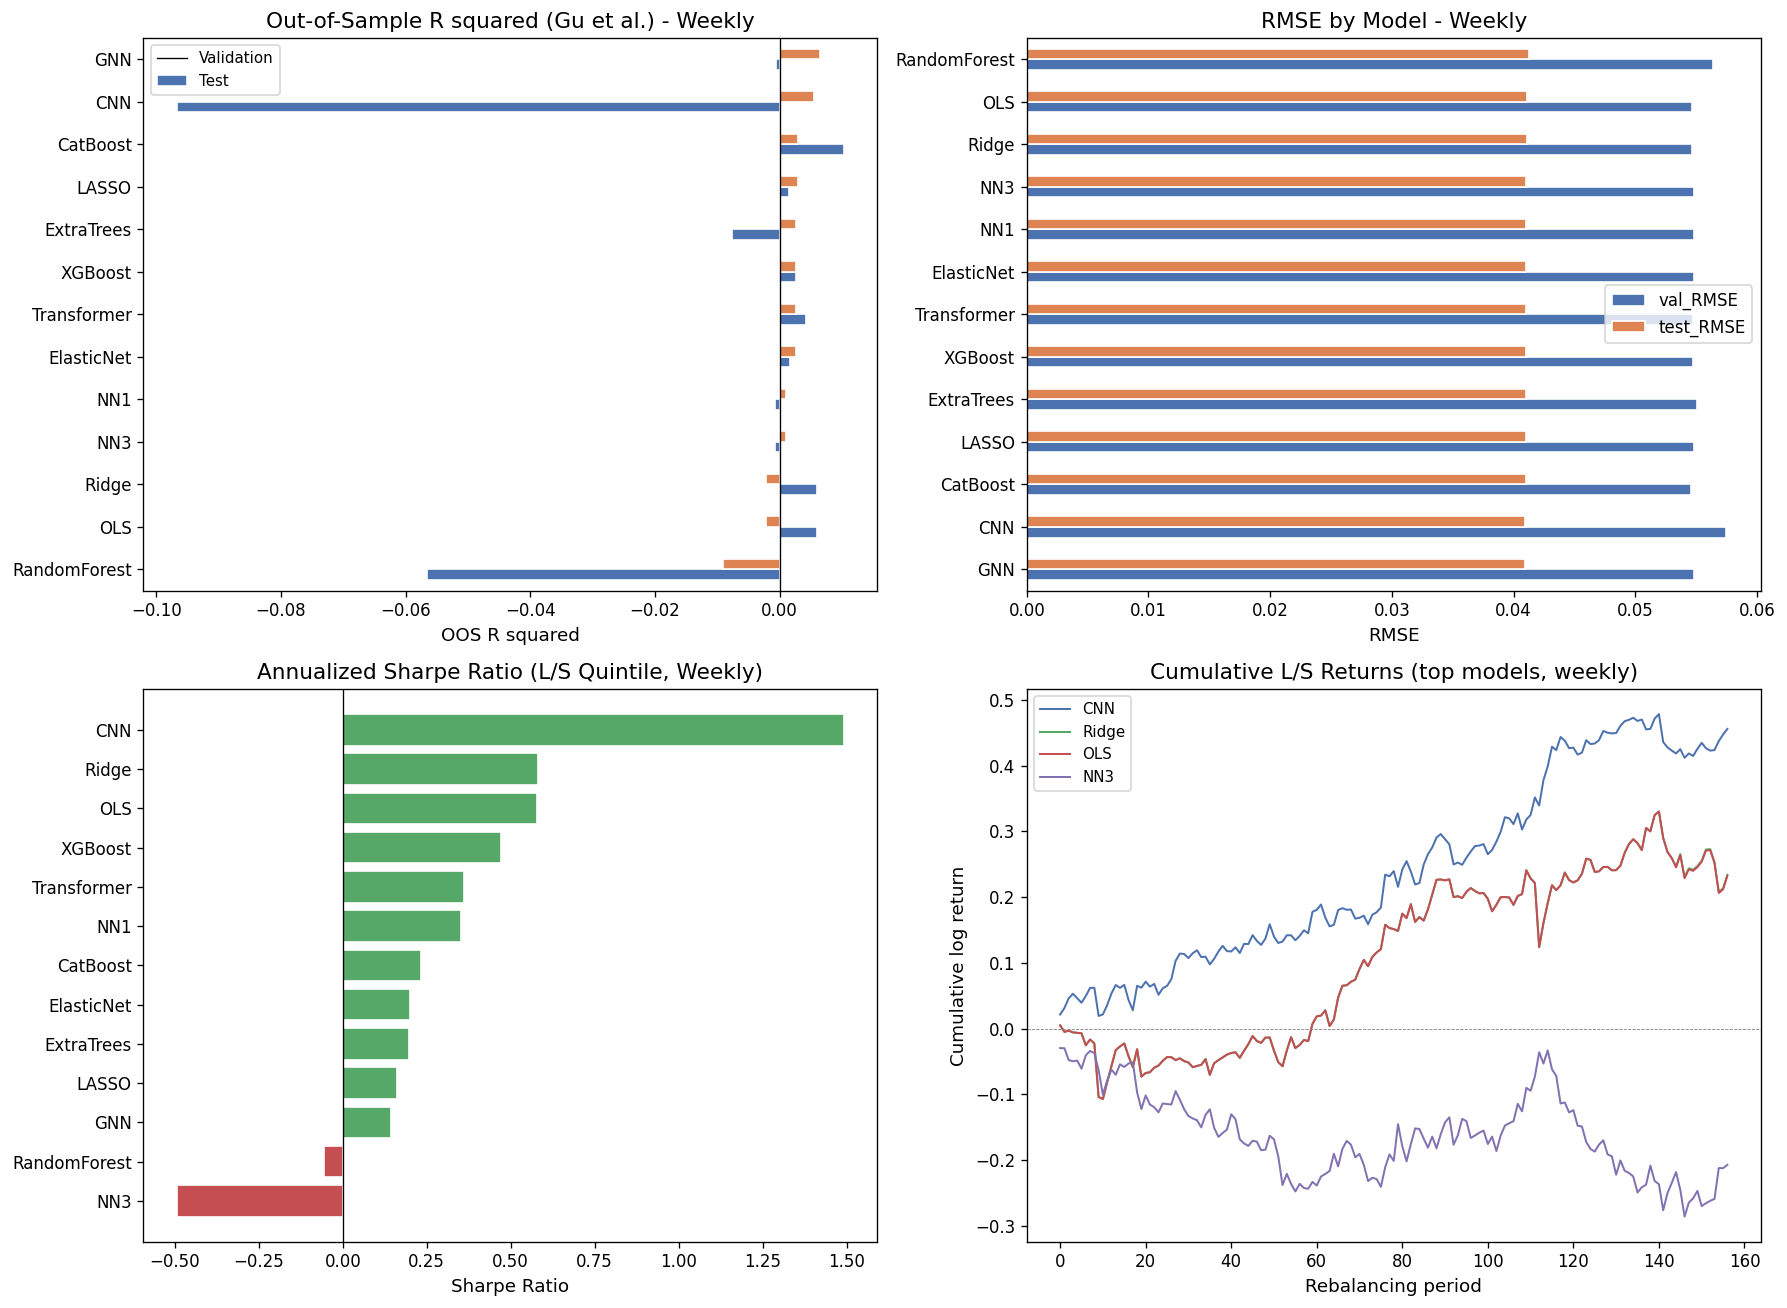

Weekly horse race complete.


In [23]:
# Visualization: Model comparison (Weekly)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

ax = axes[0, 0]
r2_data = results_weekly_df[['val_R2_oos', 'test_R2_oos']].sort_values('test_R2_oos', ascending=True)
r2_data.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Out-of-Sample R squared (Gu et al.) - Weekly')
ax.set_xlabel('OOS R squared')
ax.legend(['Validation', 'Test'], fontsize=9)

ax = axes[0, 1]
rmse_data = results_weekly_df[['val_RMSE', 'test_RMSE']].sort_values('test_RMSE', ascending=True)
rmse_data.plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='white')
ax.set_title('RMSE by Model - Weekly')
ax.set_xlabel('RMSE')

ax = axes[1, 0]
sharpe_vals = portfolio_weekly_df['Sharpe'].sort_values()
colors = ['#55A868' if v > 0 else '#C44E52' for v in sharpe_vals]
ax.barh(sharpe_vals.index, sharpe_vals.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Annualized Sharpe Ratio (L/S Quintile, Weekly)')
ax.set_xlabel('Sharpe Ratio')

ax = axes[1, 1]
top_models = portfolio_weekly_df['Sharpe'].abs().nlargest(4).index
colors_line = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
for i, name in enumerate(top_models):
    cum = portfolio_results_weekly[name]['cum_rets']
    ax.plot(range(len(cum)), cum, label=name, lw=1.2, color=colors_line[i % len(colors_line)])
ax.set_title('Cumulative L/S Returns (top models, weekly)')
ax.set_ylabel('Cumulative log return')
ax.set_xlabel('Rebalancing period')
ax.legend(fontsize=9)
ax.axhline(0, color='grey', lw=0.5, ls='--')

plt.tight_layout()
plt.show()
print("Weekly horse race complete.")

## PART 4: Ridge + Polynomial Interactions (AIPT-style)

In [24]:
from sklearn.preprocessing import PolynomialFeatures

# Base features only (exclude ranks and macro)
base_feat_cols = [c for c in feature_cols
                  if '_rank' not in c
                  and c not in macro.columns]

print(f"Base features for interactions: {len(base_feat_cols)}")
print(f"Features: {base_feat_cols}")

# Degree-2 polynomial interactions
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)

X_train_base = panel_model.loc[train_mask, base_feat_cols].values.copy()  # .copy() здесь
X_val_base   = panel_model.loc[val_mask, base_feat_cols].values.copy()
X_test_base  = panel_model.loc[test_mask, base_feat_cols].values.copy()

for arr in [X_train_base, X_val_base, X_test_base]:
    arr[~np.isfinite(arr)] = 0

X_train_poly = poly.fit_transform(X_train_base)
X_val_poly   = poly.transform(X_val_base)
X_test_poly  = poly.transform(X_test_base)

print(f"Polynomial feature matrix: {X_train_poly.shape[1]} features (from {len(base_feat_cols)} base)")
print(f"P/N ratio: {X_train_poly.shape[1] / X_train_poly.shape[0]:.4f}")

# Standardize
scaler_poly = StandardScaler()
X_train_poly_s = scaler_poly.fit_transform(X_train_poly)
X_val_poly_s   = scaler_poly.transform(X_val_poly)
X_test_poly_s  = scaler_poly.transform(X_test_poly)

for arr in [X_train_poly_s, X_val_poly_s, X_test_poly_s]:
    arr[~np.isfinite(arr)] = 0

Base features for interactions: 19
Features: ['mom_5d', 'mom_10d', 'mom_21d', 'mom_63d', 'mom_252d', 'reversal_1d', 'vol_5d', 'vol_21d', 'vol_63d', 'price_to_ma10', 'price_to_ma21', 'price_to_ma50', 'price_to_ma200', 'dist_52w_high', 'dist_52w_low', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5']
Polynomial feature matrix: 209 features (from 19 base)
P/N ratio: 0.0001


In [25]:
# Ridge with validation-based alpha selection on polynomial features
print("Training Ridge on polynomial features...")
alphas = np.logspace(-2, 6, 50)

best_alpha = None
best_r2 = -np.inf

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly_s, y_train)
    pred_val = ridge.predict(X_val_poly_s)
    r2 = oos_r2(y_val, pred_val)
    if r2 > best_r2:
        best_r2 = r2
        best_alpha = alpha

print(f"Best alpha: {best_alpha:.2f} (val OOS R squared = {best_r2:.4f})")

ridge_poly = Ridge(alpha=best_alpha)
ridge_poly.fit(X_train_poly_s, y_train)

pred_val_poly  = ridge_poly.predict(X_val_poly_s)
pred_test_poly = ridge_poly.predict(X_test_poly_s)

poly_results = {
    'val_R2_oos':  oos_r2(y_val, pred_val_poly),
    'test_R2_oos': oos_r2(y_test, pred_test_poly),
    'val_RMSE':    np.sqrt(mean_squared_error(y_val, pred_val_poly)),
    'test_RMSE':   np.sqrt(mean_squared_error(y_test, pred_test_poly)),
}

sharpe_poly, period_rets_poly = compute_portfolio_sharpe(test_panel, pred_test_poly)
poly_results['Sharpe'] = sharpe_poly
poly_results['Ann_Return'] = np.mean(period_rets_poly) * (252/5)
poly_results['Ann_Vol'] = np.std(period_rets_poly) * np.sqrt(252/5)

print(f"\nRidge+Poly Results:")
for k, v in poly_results.items():
    print(f"  {k}: {v:.4f}")

print(f"\nComparison: Standard Ridge vs Ridge+Poly")
print(f"  Ridge (base features):     OOS R2 = {results_weekly['Ridge']['test_R2_oos']:.4f}, Sharpe = {portfolio_results_weekly['Ridge']['Sharpe']:.2f}")
print(f"  Ridge+Poly ({X_train_poly.shape[1]} features): OOS R2 = {poly_results['test_R2_oos']:.4f}, Sharpe = {sharpe_poly:.2f}")

Training Ridge on polynomial features...
Best alpha: 10985.41 (val OOS R squared = 0.0110)

Ridge+Poly Results:
  val_R2_oos: 0.0110
  test_R2_oos: -0.0008
  val_RMSE: 0.0545
  test_RMSE: 0.0411
  Sharpe: 0.4628
  Ann_Return: 0.0585
  Ann_Vol: 0.1263

Comparison: Standard Ridge vs Ridge+Poly
  Ridge (base features):     OOS R2 = -0.0022, Sharpe = 0.58
  Ridge+Poly (209 features): OOS R2 = -0.0008, Sharpe = 0.46


Computing complexity path...
  P=    5: OOS R squared = 0.0020
  P=   10: OOS R squared = 0.0022
  P=   20: OOS R squared = 0.0014
  P=   30: OOS R squared = 0.0016
  P=   50: OOS R squared = 0.0012
  P=  100: OOS R squared = -0.0001
  P=  200: OOS R squared = -0.0008
  P=  209: OOS R squared = -0.0008


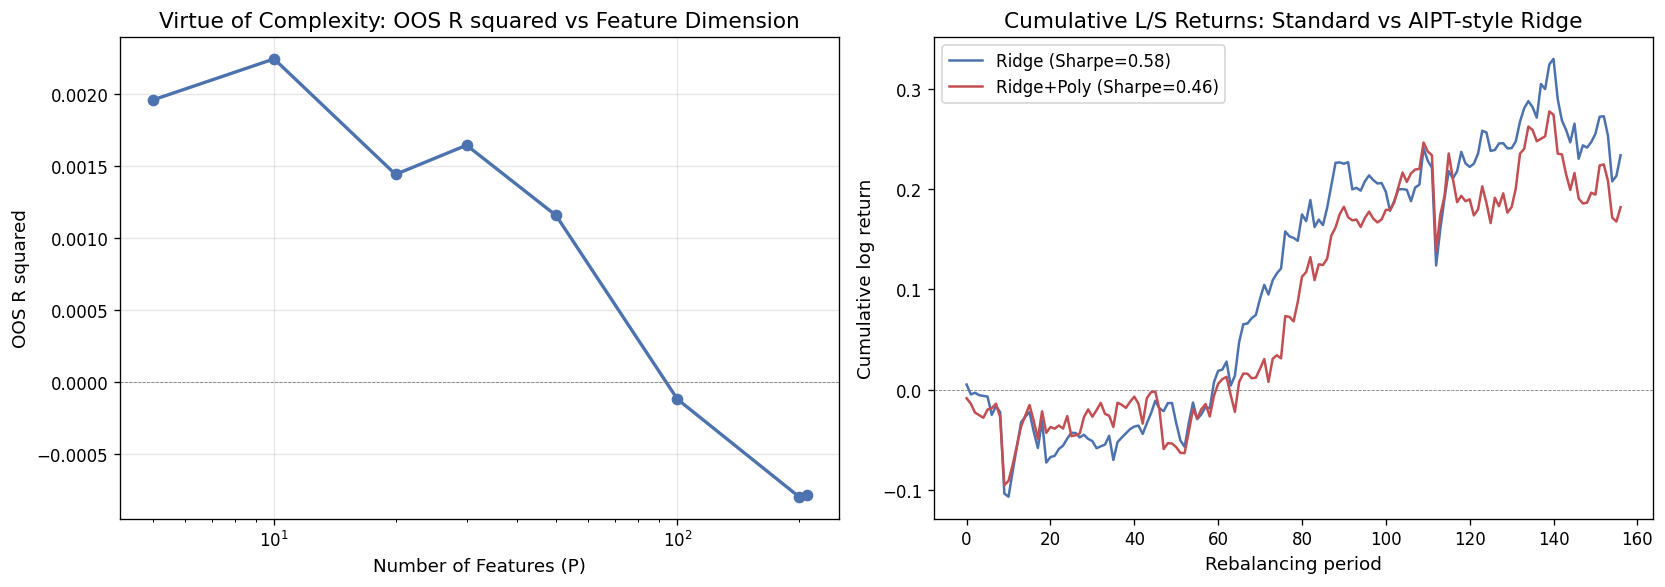

In [26]:
# Virtue of complexity: R squared vs number of features
print("Computing complexity path...")

complexity_r2 = []
n_features_list = [5, 10, 20, 30, 50, 100, 200, X_train_poly_s.shape[1]]

for n_feat in n_features_list:
    if n_feat > X_train_poly_s.shape[1]:
        continue
    X_tr = X_train_poly_s[:, :n_feat]
    X_te = X_test_poly_s[:, :n_feat]
    ridge_temp = Ridge(alpha=best_alpha)
    ridge_temp.fit(X_tr, y_train)
    pred = ridge_temp.predict(X_te)
    r2 = oos_r2(y_test, pred)
    complexity_r2.append((n_feat, r2))
    print(f"  P={n_feat:5d}: OOS R squared = {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
dims, r2s = zip(*complexity_r2)
ax.plot(dims, r2s, 'o-', color='#4C72B0', lw=2, markersize=6)
ax.set_xlabel('Number of Features (P)')
ax.set_ylabel('OOS R squared')
ax.set_title('Virtue of Complexity: OOS R squared vs Feature Dimension')
ax.set_xscale('log')
ax.axhline(0, color='grey', ls='--', lw=0.5)
ax.grid(alpha=0.3)

ax = axes[1]
# Cumulative returns comparison
sharpe_ridge, pr_ridge = compute_portfolio_sharpe(test_panel, predictions_test_weekly['Ridge'])
cum_ridge = np.cumsum(pr_ridge)
cum_poly = np.cumsum(period_rets_poly)

ax.plot(range(len(cum_ridge)), cum_ridge,
        label=f'Ridge (Sharpe={portfolio_results_weekly["Ridge"]["Sharpe"]:.2f})',
        color='#4C72B0', lw=1.5)
ax.plot(range(len(cum_poly)), cum_poly,
        label=f'Ridge+Poly (Sharpe={sharpe_poly:.2f})',
        color='#C44E52', lw=1.5)
ax.set_title('Cumulative L/S Returns: Standard vs AIPT-style Ridge')
ax.set_ylabel('Cumulative log return')
ax.set_xlabel('Rebalancing period')
ax.legend(fontsize=10)
ax.axhline(0, color='grey', ls='--', lw=0.5)

plt.tight_layout()
plt.show()

## PART 5: Economic Interpretation

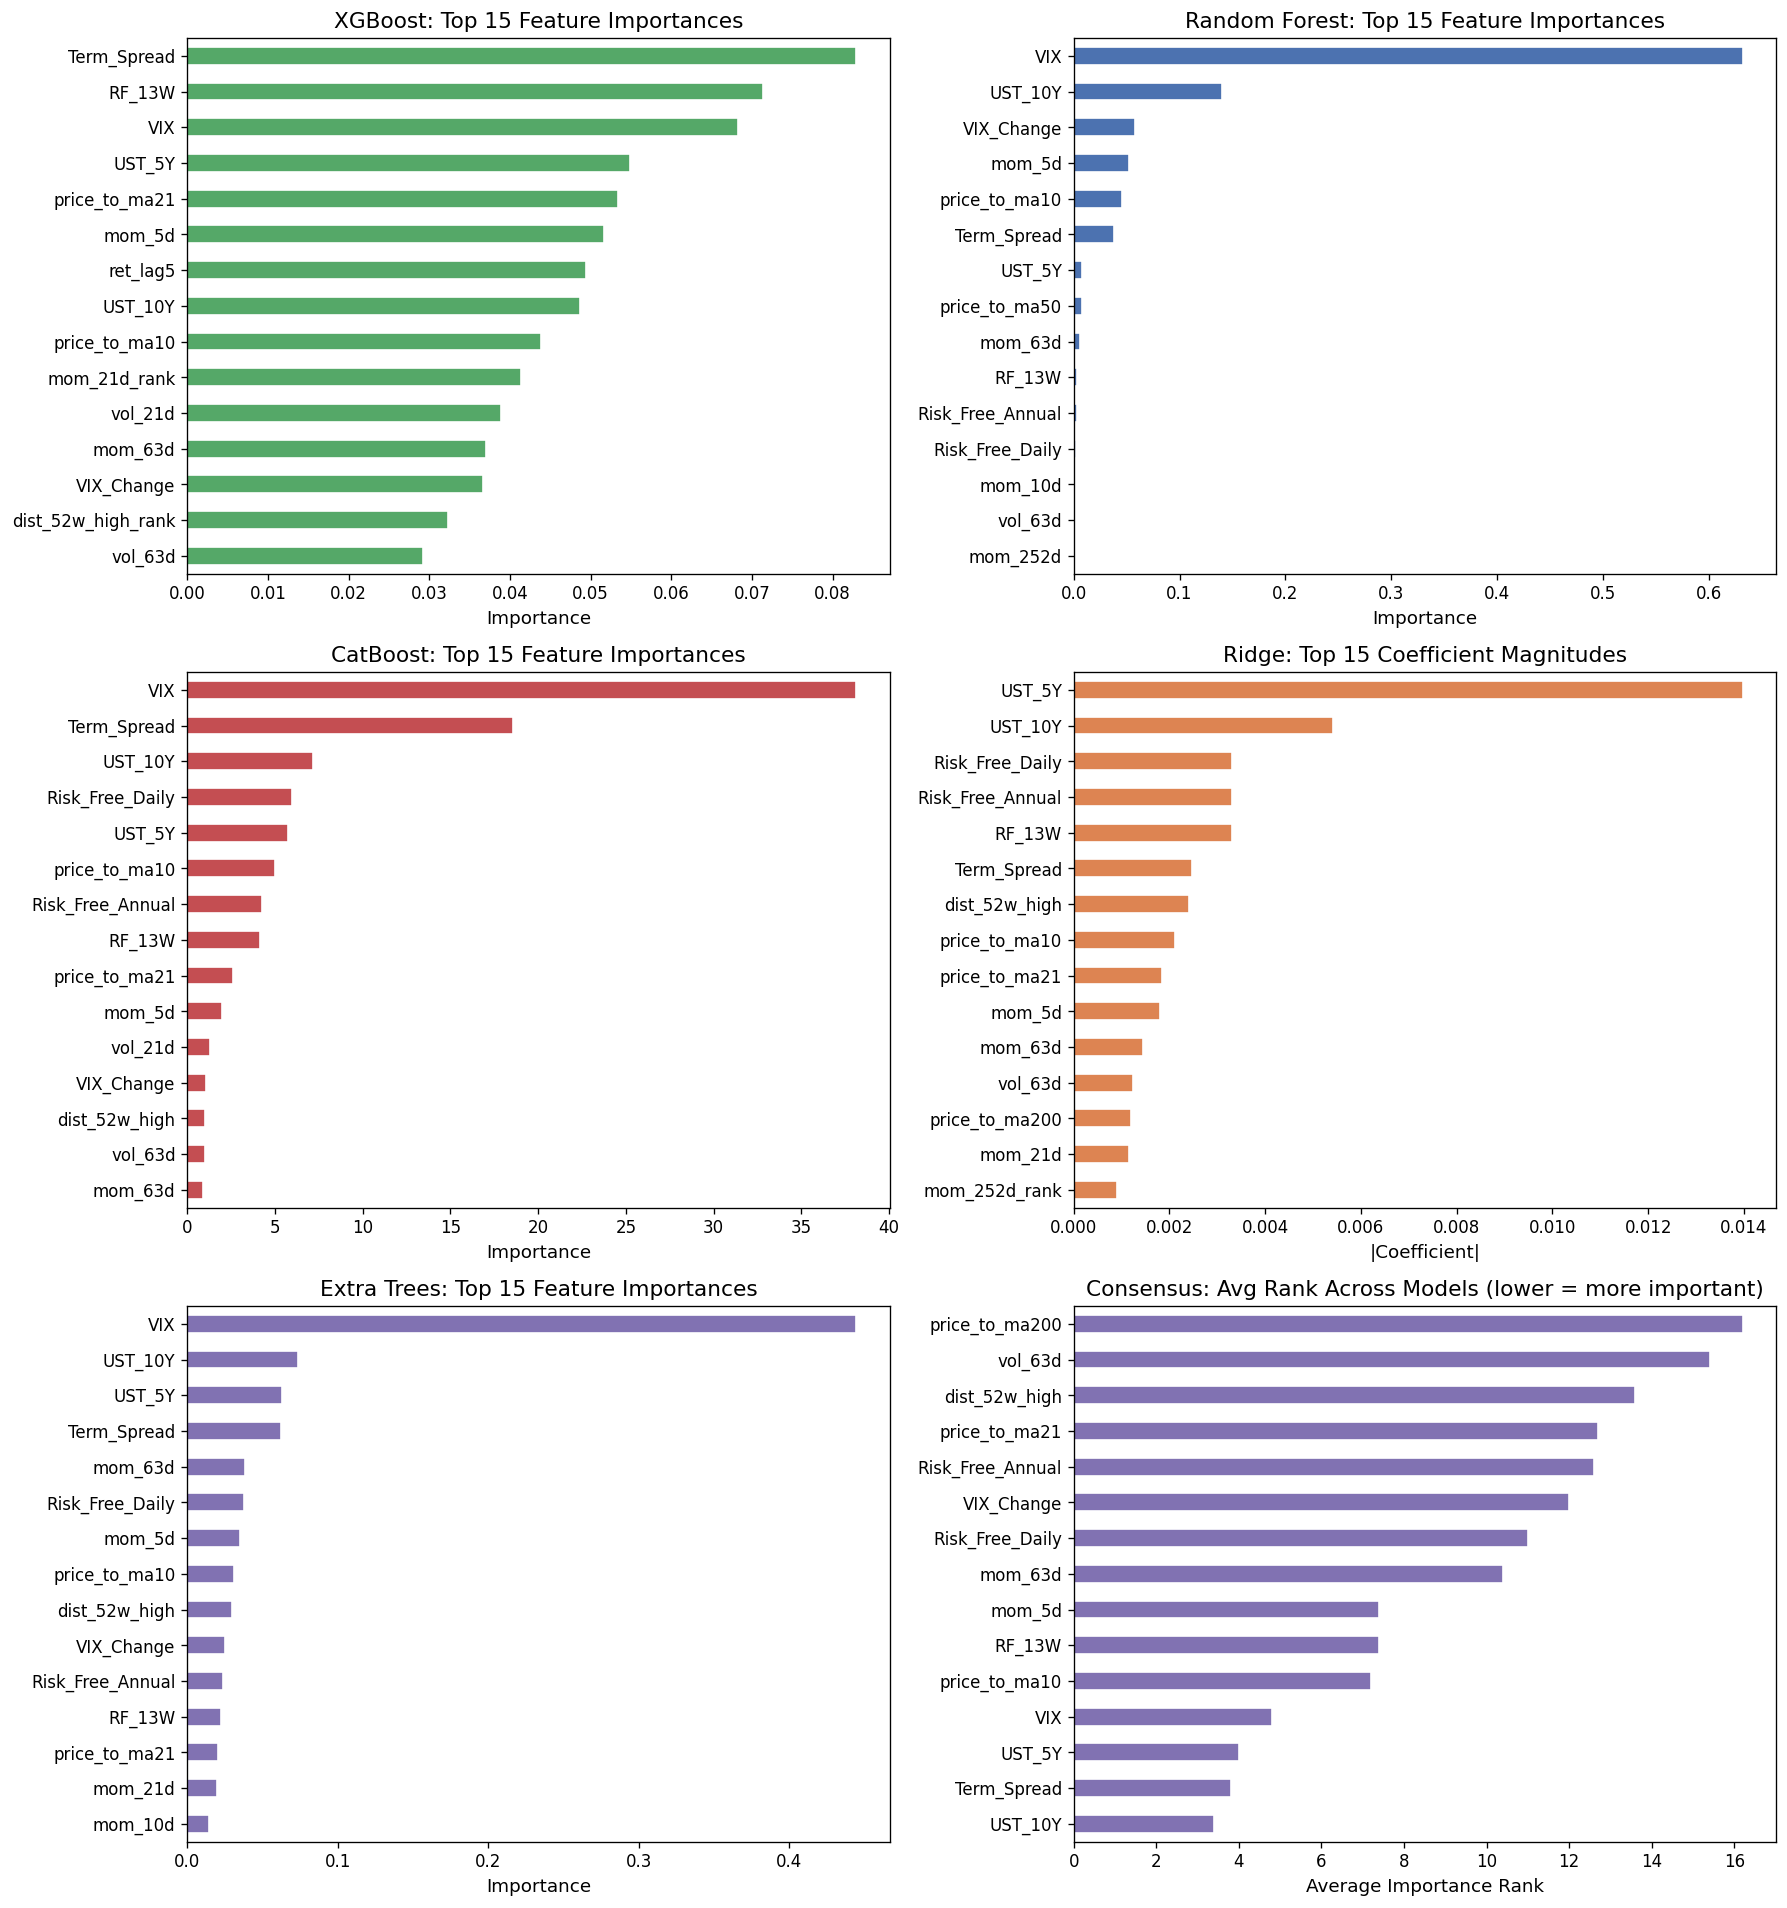

Top 10 features by consensus:
  1. UST_10Y (avg rank: 3.4)
  2. Term_Spread (avg rank: 3.8)
  3. UST_5Y (avg rank: 4.0)
  4. VIX (avg rank: 4.8)
  5. price_to_ma10 (avg rank: 7.2)
  6. RF_13W (avg rank: 7.4)
  7. mom_5d (avg rank: 7.4)
  8. mom_63d (avg rank: 10.4)
  9. Risk_Free_Daily (avg rank: 11.0)
  10. VIX_Change (avg rank: 12.0)


In [27]:
# Feature importance from weekly models (tree-based and Ridge)

fig, axes = plt.subplots(3, 2, figsize=(15, 16))

ax = axes[0, 0]
xgb_model = models_weekly['XGBoost']                # <-- XGBoost вместо GradBoost
feat_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp.tail(15).plot(kind='barh', ax=ax, color='#55A868', edgecolor='white')
ax.set_title('XGBoost: Top 15 Feature Importances')  # <-- название
ax.set_xlabel('Importance')

ax = axes[0, 1]
rf_model = models_weekly['RandomForest']             # <-- models_weekly
feat_imp_rf = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp_rf.tail(15).plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Random Forest: Top 15 Feature Importances')
ax.set_xlabel('Importance')

ax = axes[1, 0]
cb_model = models_weekly['CatBoost']                 # <-- models_weekly
feat_imp_cb = pd.Series(cb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp_cb.tail(15).plot(kind='barh', ax=ax, color='#C44E52', edgecolor='white')
ax.set_title('CatBoost: Top 15 Feature Importances')
ax.set_xlabel('Importance')

ax = axes[1, 1]
ridge_model = models_weekly['Ridge']                 # <-- models_weekly
ridge_coefs = pd.Series(np.abs(ridge_model.coef_), index=feature_cols).sort_values(ascending=True)
ridge_coefs.tail(15).plot(kind='barh', ax=ax, color='#DD8452', edgecolor='white')
ax.set_title('Ridge: Top 15 Coefficient Magnitudes')
ax.set_xlabel('|Coefficient|')

ax = axes[2, 0]
et_model = models_weekly['ExtraTrees']               # <-- models_weekly
feat_imp_et = pd.Series(et_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp_et.tail(15).plot(kind='barh', ax=ax, color='#8172B2', edgecolor='white')
ax.set_title('Extra Trees: Top 15 Feature Importances')
ax.set_xlabel('Importance')

ax = axes[2, 1]
ranks = pd.DataFrame({
    'XGBoost': feat_imp.rank(ascending=False),       # <-- XGBoost
    'RandomForest': feat_imp_rf.rank(ascending=False),
    'CatBoost': feat_imp_cb.rank(ascending=False),
    'ExtraTrees': feat_imp_et.rank(ascending=False),
    'Ridge': ridge_coefs.rank(ascending=False),
})
avg_rank = ranks.mean(axis=1).sort_values(ascending=True)
avg_rank.head(15).plot(kind='barh', ax=ax, color='#8172B2', edgecolor='white')
ax.set_title('Consensus: Avg Rank Across Models (lower = more important)')
ax.set_xlabel('Average Importance Rank')

plt.tight_layout()
plt.show()

print("Top 10 features by consensus:")
for i, (feat, rank) in enumerate(avg_rank.head(10).items()):
    print(f"  {i+1}. {feat} (avg rank: {rank:.1f})")

In [28]:
# Macro-regime analysis (weekly target, XGBoost)

regimes = {
    'Dot-com crash (2000-02)':      ('2000-01-01', '2002-12-31'),
    'Recovery (2003-06)':           ('2003-01-01', '2006-12-31'),
    'GFC (2007-09)':                ('2007-01-01', '2009-06-30'),
    'Post-GFC bull (2009H2-15)':    ('2009-07-01', '2015-12-31'),
    'Pre-COVID (2016-19)':          ('2016-01-01', '2019-12-31'),
    'COVID crash (2020 Q1-Q2)':     ('2020-01-01', '2020-06-30'),
    'Recovery & stimulus (2020H2-21)': ('2020-07-01', '2021-12-31'),
    'Rate hikes (2022)':            ('2022-01-01', '2022-12-31'),
    'Transition (2023)':            ('2023-01-01', '2023-12-31'),
    'Normalization (2024-26)':      ('2024-01-01', '2026-12-31'),
}

X_full = panel_model[feature_cols].values.copy()
X_full[~np.isfinite(X_full)] = 0
X_full_s = scaler.transform(X_full)
X_full_s[~np.isfinite(X_full_s)] = 0

full_pred_xgb = models_weekly['XGBoost'].predict(X_full_s)
panel_model = panel_model.copy()
panel_model['pred_xgb'] = full_pred_xgb

regime_stats = []
for regime_name, (start, end) in regimes.items():
    mask = (panel_model['date'] >= start) & (panel_model['date'] <= end)
    sub = panel_model.loc[mask]
    if len(sub) == 0:
        continue

    actual = sub['ret_5d_fwd'].values
    pred   = sub['pred_xgb'].values
    valid  = np.isfinite(actual) & np.isfinite(pred)
    actual, pred = actual[valid], pred[valid]

    r2 = oos_r2(actual, pred) if len(actual) > 10 else np.nan
    ret_disp = np.std(actual)
    vol_median = sub['vol_21d'].median()

    regime_stats.append({
        'Regime': regime_name,
        'N_obs': len(actual),
        'OOS_R2': r2,
        'Return_Dispersion': ret_disp,
        'Median_Vol_21d': vol_median,
    })

regime_df = pd.DataFrame(regime_stats)
print("Macro Regime Analysis (XGBoost, weekly target):\n")
print(regime_df.to_string(index=False))

Macro Regime Analysis (XGBoost, weekly target):

                         Regime  N_obs    OOS_R2  Return_Dispersion  Median_Vol_21d
        Dot-com crash (2000-02) 221840  0.011805           0.067649        0.023765
             Recovery (2003-06) 297065  0.010164           0.037836        0.013519
                  GFC (2007-09) 185260  0.092774           0.068541        0.020646
      Post-GFC bull (2009H2-15) 483210  0.027261           0.036901        0.013188
            Pre-COVID (2016-19) 296770  0.014955           0.035229        0.012610
       COVID crash (2020 Q1-Q2)  36875 -0.003204           0.092155        0.027158
Recovery & stimulus (2020H2-21) 112100  0.022671           0.039919        0.015857
              Rate hikes (2022)  74045 -0.007716           0.048430        0.018957
              Transition (2023)  73750  0.001104           0.038276        0.014438
        Normalization (2024-26) 157235  0.003255           0.042183        0.014681


In [29]:
# Combined summary: Daily vs Weekly vs AIPT

print("="*90)
print("COMPREHENSIVE MODEL COMPARISON: Daily vs Weekly Target")
print("="*90)

# Build daily summary
daily_summary = results_daily_df[['test_R2_oos', 'test_RMSE']].copy()
daily_summary['Sharpe'] = [portfolio_results_daily[m]['Sharpe'] for m in daily_summary.index]
daily_summary['Ann_Return'] = [portfolio_results_daily[m]['Ann_Return'] for m in daily_summary.index]
daily_summary.columns = ['R2_daily', 'RMSE_daily', 'Sharpe_daily', 'AnnRet_daily']

# Build weekly summary
weekly_summary = results_weekly_df[['test_R2_oos', 'test_RMSE']].copy()
weekly_summary['Sharpe'] = [portfolio_results_weekly[m]['Sharpe'] for m in weekly_summary.index]
weekly_summary['Ann_Return'] = [portfolio_results_weekly[m]['Ann_Return'] for m in weekly_summary.index]
weekly_summary.columns = ['R2_weekly', 'RMSE_weekly', 'Sharpe_weekly', 'AnnRet_weekly']

# Merge
comparison = daily_summary.join(weekly_summary)

# Add AIPT row (weekly only)
comparison.loc['Ridge+Poly (AIPT)'] = {
    'R2_daily': np.nan, 'RMSE_daily': np.nan, 'Sharpe_daily': np.nan, 'AnnRet_daily': np.nan,
    'R2_weekly': poly_results['test_R2_oos'], 'RMSE_weekly': poly_results['test_RMSE'],
    'Sharpe_weekly': poly_results['Sharpe'], 'AnnRet_weekly': poly_results['Ann_Return'],
}

# Format for display
fmt = comparison.copy()
for c in ['R2_daily', 'R2_weekly']:
    fmt[c] = fmt[c].map(lambda x: f'{x:.4f}' if pd.notna(x) else '-')
for c in ['RMSE_daily', 'RMSE_weekly']:
    fmt[c] = fmt[c].map(lambda x: f'{x:.4f}' if pd.notna(x) else '-')
for c in ['Sharpe_daily', 'Sharpe_weekly']:
    fmt[c] = fmt[c].map(lambda x: f'{x:+.2f}' if pd.notna(x) else '-')
for c in ['AnnRet_daily', 'AnnRet_weekly']:
    fmt[c] = fmt[c].map(lambda x: f'{x:+.1%}' if pd.notna(x) else '-')

fmt.columns = ['R2(D)', 'RMSE(D)', 'Sharpe(D)', 'Ret(D)', 'R2(W)', 'RMSE(W)', 'Sharpe(W)', 'Ret(W)']
print(fmt.to_string())

# Highlight key findings
print("\nKey findings:")
best_daily_sharpe = comparison['Sharpe_daily'].dropna().idxmax()
best_weekly_sharpe = comparison['Sharpe_weekly'].dropna().idxmax()
best_daily_r2 = comparison['R2_daily'].dropna().idxmax()
best_weekly_r2 = comparison['R2_weekly'].dropna().idxmax()

print(f"  Best Sharpe (daily):  {best_daily_sharpe} ({comparison.loc[best_daily_sharpe, 'Sharpe_daily']:+.2f})")
print(f"  Best Sharpe (weekly): {best_weekly_sharpe} ({comparison.loc[best_weekly_sharpe, 'Sharpe_weekly']:+.2f})")
print(f"  Best R2 (daily):      {best_daily_r2} ({comparison.loc[best_daily_r2, 'R2_daily']:.4f})")
print(f"  Best R2 (weekly):     {best_weekly_r2} ({comparison.loc[best_weekly_r2, 'R2_weekly']:.4f})")

COMPREHENSIVE MODEL COMPARISON: Daily vs Weekly Target
                     R2(D) RMSE(D) Sharpe(D) Ret(D)    R2(W) RMSE(W) Sharpe(W)  Ret(W)
OLS                -0.0006  0.0188     +0.41  +5.7%  -0.0023  0.0411     +0.58   +7.5%
Ridge              -0.0006  0.0188     +0.41  +5.7%  -0.0022  0.0411     +0.58   +7.5%
LASSO               0.0006  0.0188     -0.48  -6.4%   0.0029  0.0410     +0.16   +2.2%
ElasticNet          0.0009  0.0188     +0.22  +3.3%   0.0025  0.0410     +0.20   +2.6%
RandomForest       -0.0038  0.0188     -0.48  -5.2%  -0.0091  0.0412     -0.06   -0.6%
XGBoost            -0.0182  0.0189     +0.18  +2.5%   0.0027  0.0410     +0.47   +6.2%
ExtraTrees         -0.0014  0.0188     +0.26  +4.0%   0.0027  0.0410     +0.20   +2.7%
CatBoost           -0.0030  0.0188     +0.29  +4.1%   0.0030  0.0410     +0.23   +3.1%
NN1                 0.0002  0.0188     -0.21  -3.0%   0.0009  0.0410     +0.35   +5.5%
NN3                 0.0002  0.0188     -0.48  -6.4%   0.0009  0.0410     -0